IMPORTING DATASETS PLSDA

In [1]:
import pandas as pd

global_stability_Lisbon_plsda = pd.read_pickle('global_stable_counts_Lisbon_threshold.pkl')
print(len(global_stability_Lisbon_plsda))
global_stability_Coimbra_plsda = pd.read_pickle('global_stability_Coimbra_threshold.pkl')
print(len(global_stability_Coimbra_plsda))
global_stability_LC_plsda = pd.read_pickle('global_stability_LC_threshold.pkl')
print(len(global_stability_LC_plsda))
global_stability_coimbraonlisbon_plsda = pd.read_pickle('global_stable_counts_coimbraonlisbon_threshold.pkl')
print(len(global_stability_coimbraonlisbon_plsda))
global_stability_LisbononCoimbra_plsda = pd.read_pickle('global_stability_LisbononCoimbra_threshold.pkl')
print(len(global_stability_LisbononCoimbra_plsda))


255
237
201
201
201


DISCARDING THE PROTEINS WITH FREQ = 0

In [2]:
print((global_stability_Lisbon_plsda == 0).sum())
print((global_stability_Coimbra_plsda == 0).sum())
print((global_stability_LC_plsda == 0).sum())
print((global_stability_coimbraonlisbon_plsda == 0).sum())
print((global_stability_LisbononCoimbra_plsda == 0).sum())

4
95
40
47
52


In [3]:
global_stability_Lisbon_plsda = global_stability_Lisbon_plsda[global_stability_Lisbon_plsda > 0]
global_stability_Coimbra_plsda = global_stability_Coimbra_plsda[global_stability_Coimbra_plsda > 0]
global_stability_LC_plsda = global_stability_LC_plsda[global_stability_LC_plsda > 0]
global_stability_coimbraonlisbon_plsda = global_stability_coimbraonlisbon_plsda[global_stability_coimbraonlisbon_plsda > 0]
global_stability_LisbononCoimbra_plsda = global_stability_LisbononCoimbra_plsda[global_stability_LisbononCoimbra_plsda > 0]
print(len(global_stability_Lisbon_plsda))
print(len(global_stability_Coimbra_plsda))
print(len(global_stability_LC_plsda))
print(len(global_stability_coimbraonlisbon_plsda))
print(len(global_stability_LisbononCoimbra_plsda))

251
142
161
154
149


IMPORTING DATASETS RANDOM FOREST

In [4]:
global_stability_LC_rf = pd.read_pickle('feature_freq_LC_rf_threshold.pkl')
print(len(global_stability_LC_rf))
global_stability_Lisbon_rf = pd.read_pickle('feature_rf_Lisbon_threshold.pkl')
print(len(global_stability_Lisbon_rf))
global_stability_Coimbra_rf = pd.read_pickle('feature_rf_Cooimbra_threshold.pkl')
print(len(global_stability_Coimbra_rf))
global_stability_CoimbraonLisbon_rf = pd.read_pickle('feat_freq_CoimbraonLisbon_rf_threshold.pkl')
print(len(global_stability_CoimbraonLisbon_rf))
global_stability_LisbononCoimbra_rf = pd.read_pickle('feat_freq_LisbononCoimbra_rf_threshold.pkl')
print(len(global_stability_LisbononCoimbra_rf))

157
209
139
83
126


DISCARDING THE FEATURE WITH FREQ = 0

In [5]:
global_stability_LC_rf = global_stability_LC_rf[global_stability_LC_rf > 0]
global_stability_Lisbon_rf = global_stability_Lisbon_rf[global_stability_Lisbon_rf > 0]
global_stability_Coimbra_rf = global_stability_Coimbra_rf[global_stability_Coimbra_rf > 0]
global_stability_CoimbraonLisbon_rf = global_stability_CoimbraonLisbon_rf[global_stability_CoimbraonLisbon_rf > 0]
global_stability_LisbononCoimbra_rf = global_stability_LisbononCoimbra_rf[global_stability_LisbononCoimbra_rf > 0]
print(len(global_stability_LC_rf))
print(len(global_stability_Lisbon_rf))
print(len(global_stability_Coimbra_rf))
print(len(global_stability_CoimbraonLisbon_rf))
print(len(global_stability_LisbononCoimbra_rf))

157
209
139
83
126


COMPARING PLS-DA AND RANDOM FOREST ON LISBON

In [6]:
results_Lisbon_rf_threshold = pd.read_pickle('results_Lisbon_rf_threshold.pkl')
df_plsda = pd.read_pickle('df_plsda_Lisbon_threshold.pkl')

In [7]:
results_Lisbon_rf_threshold

,model,seed,mcc,auc,n_features,best_threshold
0,RF,0,0.638889,0.916667,55,0.7
1,RF,1,0.843274,0.888889,63,0.7
2,RF,2,1.000000,1.000000,71,0.7
3,RF,3,0.638889,0.916667,57,0.7
4,RF,4,0.638889,0.916667,94,0.8
5,RF,5,0.821584,1.000000,154,0.9
6,RF,6,1.000000,1.000000,109,0.8
7,RF,7,0.821584,1.000000,107,0.8
8,RF,8,1.000000,1.000000,156,0.9
9,RF,9,0.843274,0.944444,54,0.7


In [8]:
df_plsda

,model,seed,mcc,auc,n_features,best_vip_threshold,best_decision_threshold
0,PLS-DA,0,0.733799,0.956044,181,0.1,0.40
1,PLS-DA,1,0.811246,0.956044,197,0.1,0.45
2,PLS-DA,2,1.000000,1.000000,190,0.1,0.50
3,PLS-DA,3,0.898717,0.945055,21,1.0,0.45
4,PLS-DA,4,0.780220,0.945055,42,0.8,0.50
5,PLS-DA,5,0.898717,0.989011,188,0.1,0.50
6,PLS-DA,6,1.000000,1.000000,210,0.1,0.40
7,PLS-DA,7,1.000000,1.000000,72,0.5,0.40
8,PLS-DA,8,1.000000,1.000000,186,0.1,0.40
9,PLS-DA,9,0.898717,0.967033,46,0.7,0.45


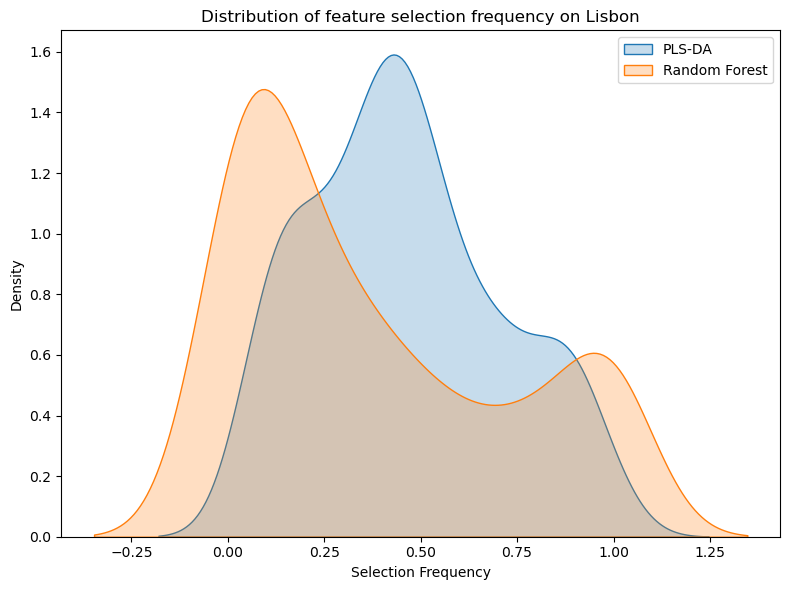

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# merge serie
df_merged = pd.concat([global_stability_Lisbon_plsda, global_stability_Lisbon_rf], axis=1)
df_merged.columns = ['freq_plsda', 'freq_rf']

# fill missing
df_merged = df_merged.fillna(0)

plt.figure(figsize=(8,6))

# KDE plot
sns.kdeplot(df_merged['freq_plsda'], label='PLS-DA', fill=True)
sns.kdeplot(df_merged['freq_rf'], label='Random Forest', fill=True)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Distribution of feature selection frequency on Lisbon')

plt.legend()
plt.tight_layout()
plt.savefig('Distribution_of_feature_selection_frequency_Lisbon')
plt.show()

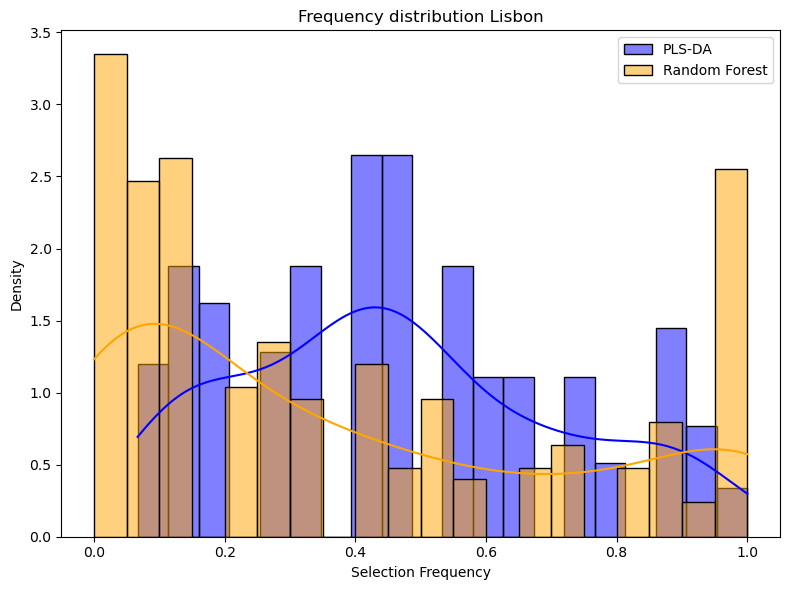

In [10]:
plt.figure(figsize=(8,6))

sns.histplot(df_merged['freq_plsda'], color='blue', label='PLS-DA', kde=True, stat='density', bins=20)
sns.histplot(df_merged['freq_rf'], color='orange', label='Random Forest', kde=True, stat='density', bins=20)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Frequency distribution Lisbon')

plt.legend()
plt.tight_layout()
plt.savefig('Frequency_distribution_Lisbon')
plt.show()

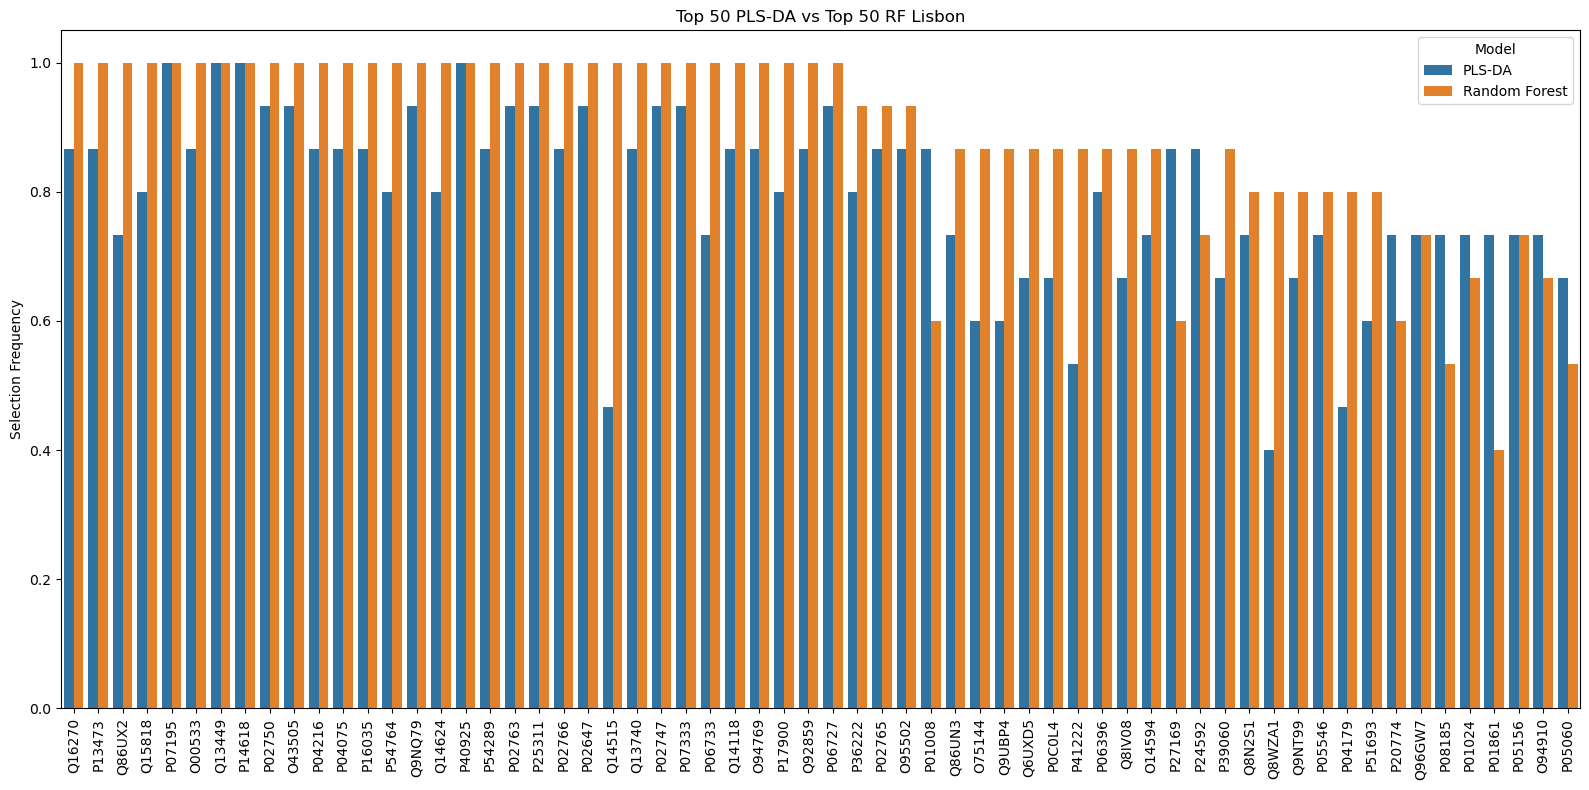

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- top 50 per ciascun modello ---
top50_plsda = global_stability_Lisbon_plsda.sort_values(ascending=False).head(50)
top50_rf = global_stability_Lisbon_rf.sort_values(ascending=False).head(50)

# --- unione delle proteine ---
proteins_union = set(top50_plsda.index).union(set(top50_rf.index))

# --- costruisci dataframe ---
df_plot = pd.DataFrame({
    'protein': list(proteins_union)
})

# aggiungi frequenze
df_plot['freq_plsda'] = df_plot['protein'].map(global_stability_Lisbon_plsda).fillna(0)
df_plot['freq_rf'] = df_plot['protein'].map(global_stability_Lisbon_rf).fillna(0)

# --- ordina (opzione 1: max frequenza) ---
df_plot['max_freq'] = df_plot[['freq_plsda', 'freq_rf']].max(axis=1)
df_plot = df_plot.sort_values('max_freq', ascending=False)

# --- reshape ---
df_melt = df_plot.melt(
    id_vars='protein',
    value_vars=['freq_plsda', 'freq_rf'],
    var_name='model',
    value_name='frequency'
)

# nomi puliti
df_melt['model'] = df_melt['model'].map({
    'freq_plsda': 'PLS-DA',
    'freq_rf': 'Random Forest'
})

# --- plot ---
plt.figure(figsize=(16,8))

sns.barplot(
    data=df_melt,
    x='protein',
    y='frequency',
    hue='model'
)

plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Selection Frequency')
plt.title('Top 50 PLS-DA vs Top 50 RF Lisbon')

plt.legend(title='Model')
plt.tight_layout()
plt.savefig('plot_top_50_Lisbon')
plt.show()

In [12]:
df = pd.concat([global_stability_Lisbon_plsda, global_stability_Lisbon_rf], axis=1)
df.columns = ['freq_plsda', 'freq_rf']
df = df.fillna(0)

def categorize(row):
    f_pls = row['freq_plsda']
    f_rf = row['freq_rf']
    
    if f_pls >= 0.5 and f_rf >= 0.5:
        return 'core'
    
    elif (f_pls >= 0.7 and f_rf < 0.3) or (f_rf >= 0.7 and f_pls < 0.3):
        return 'model_specific'
    
    elif f_pls < 0.3 and f_rf < 0.3:
        return 'noise'
    
    else:
        return 'intermediate'

df['category'] = df.apply(categorize, axis=1)

In [13]:
data = df['category'].value_counts()
data = pd.DataFrame(data)
df_extracted_Lisbon = df[(df['category'] == 'intermediate') | (df['category'] == 'core') | (df['category'] == 'model_specific')]

In [14]:
data

,count
category,
intermediate,111
core,73
noise,67


In [15]:
df_extracted_Lisbon

,freq_plsda,freq_rf,category
P40925,1.000000,1.000000,core
P14618,1.000000,1.000000,core
P07195,1.000000,1.000000,core
Q13449,1.000000,1.000000,core
P02750,0.933333,1.000000,core
...,...,...,...
P01009,0.333333,0.000000,intermediate
P00747,0.333333,0.066667,intermediate
P06312,0.266667,0.466667,intermediate
Q99574,0.200000,0.600000,intermediate


In [16]:
df_compare = pd.merge(
    results_Lisbon_rf_threshold,
    df_plsda,
    on='seed',
    suffixes=('_rf', '_plsda')
)
df_compare['diff_mcc'] = df_compare['mcc_rf'] - df_compare['mcc_plsda']

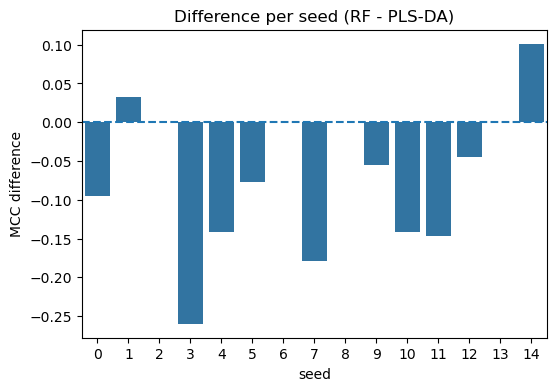

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.barplot(x='seed', y='diff_mcc', data=df_compare)

plt.axhline(0, linestyle='--')
plt.title('Difference per seed (RF - PLS-DA)')
plt.ylabel('MCC difference')

plt.show()

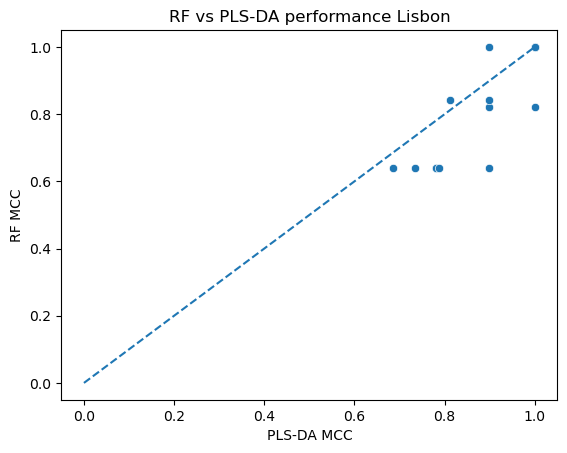

In [18]:
sns.scatterplot(
    x=df_compare['mcc_plsda'],
    y=df_compare['mcc_rf']
)

plt.plot([0,1],[0,1],'--')  # diagonale

plt.xlabel('PLS-DA MCC')
plt.ylabel('RF MCC')
plt.title('RF vs PLS-DA performance Lisbon')
plt.savefig('RF_vs_PLS_DA_performance_Lisbon')
plt.show()

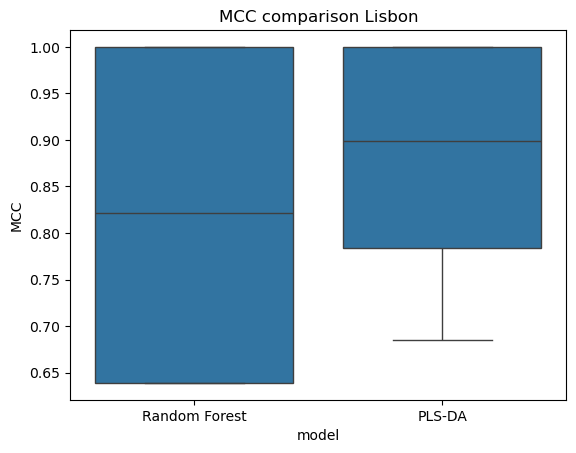

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

df_mcc = df_compare.melt(
    id_vars='seed',
    value_vars=['mcc_rf', 'mcc_plsda'],
    var_name='model',
    value_name='MCC'
)

df_mcc['model'] = df_mcc['model'].map({
    'mcc_rf': 'Random Forest',
    'mcc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='MCC', data=df_mcc)

plt.title('MCC comparison Lisbon')
plt.savefig('MCC_comparison_Lisbon')
plt.show()

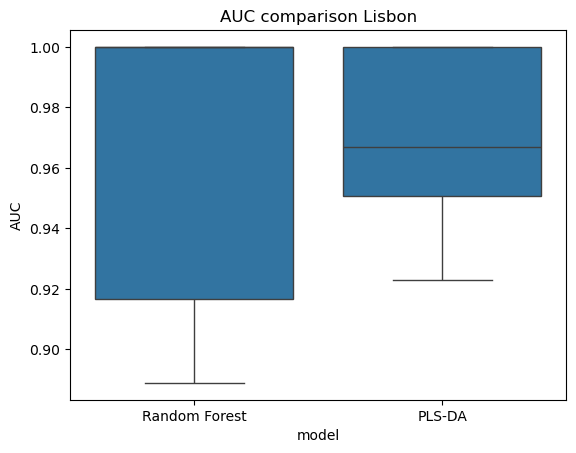

In [20]:
df_auc = df_compare.melt(
    id_vars='seed',
    value_vars=['auc_rf', 'auc_plsda'],
    var_name='model',
    value_name='AUC'
)

df_auc['model'] = df_auc['model'].map({
    'auc_rf': 'Random Forest',
    'auc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='AUC', data=df_auc)

plt.title('AUC comparison Lisbon')
plt.savefig('AUC_comparison_Lisbon')
plt.show()

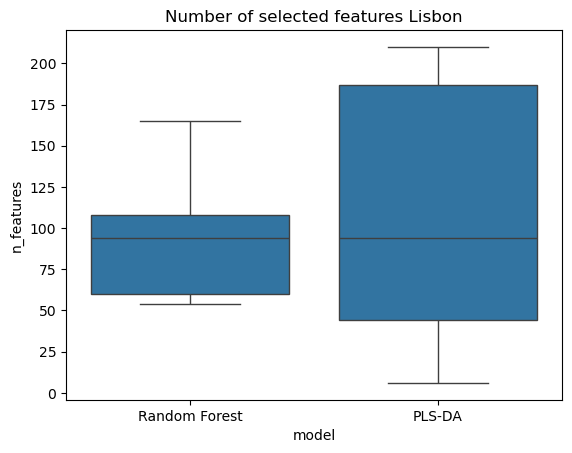

In [21]:
df_feat = df_compare.melt(
    id_vars='seed',
    value_vars=['n_features_rf', 'n_features_plsda'],
    var_name='model',
    value_name='n_features'
)

df_feat['model'] = df_feat['model'].map({
    'n_features_rf': 'Random Forest',
    'n_features_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='n_features', data=df_feat)

plt.title('Number of selected features Lisbon')
plt.savefig('Number_of_selected_features_Lisbon')
plt.show()

In [22]:
top50_plsda = set(global_stability_Lisbon_plsda.sort_values(ascending=False).head(50).index)
top50_rf = set(global_stability_Lisbon_rf.sort_values(ascending=False).head(50).index)

intersection = top50_plsda.intersection(top50_rf)
union = top50_plsda.union(top50_rf)

jaccard = len(intersection) / len(union)

print("Overlap:", len(intersection))
print("Jaccard:", jaccard)

Overlap: 38
Jaccard: 0.6129032258064516


COMPARING PLS-DA AND RANDOM FOREST ON COIMBRA

In [23]:
results_Coimbra_rf_threshold = pd.read_pickle('results_Coimbra_rf_threshold.pkl')
df_plsda_coimbra = pd.read_pickle('df_plsda_Coimbra_threshold.pkl')

In [24]:
results_Coimbra_rf_threshold

,model,seed,mcc,auc,n_features,best_threshold
0,RF,0,0.874007,1.000000,45,0.7
1,RF,1,1.000000,1.000000,43,0.7
2,RF,2,0.874007,1.000000,43,0.7
3,RF,3,1.000000,1.000000,43,0.7
4,RF,4,1.000000,1.000000,41,0.7
5,RF,5,1.000000,1.000000,44,0.7
6,RF,6,0.874007,1.000000,107,0.9
7,RF,7,0.874007,1.000000,45,0.7
8,RF,8,1.000000,1.000000,108,0.9
9,RF,9,0.751068,0.954545,31,0.7


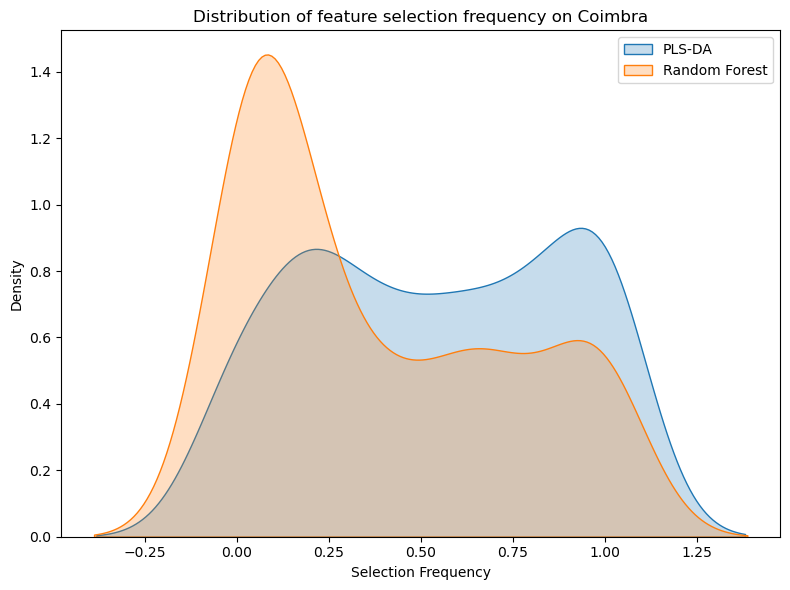

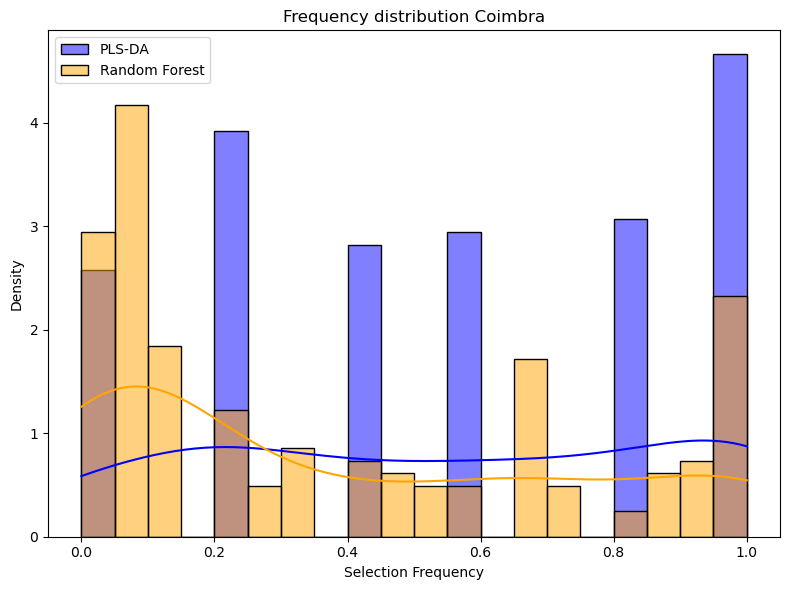

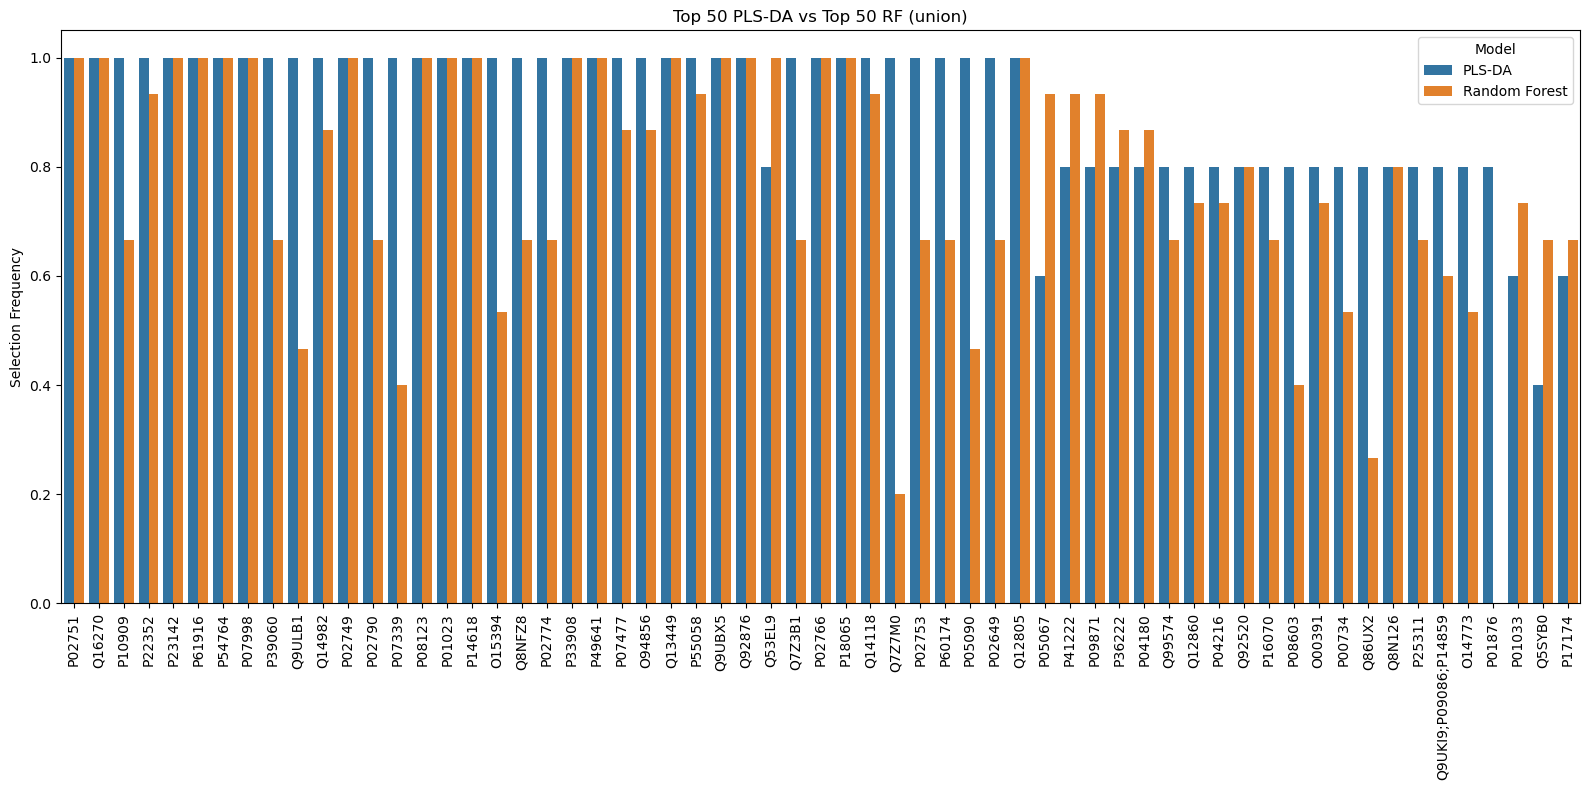

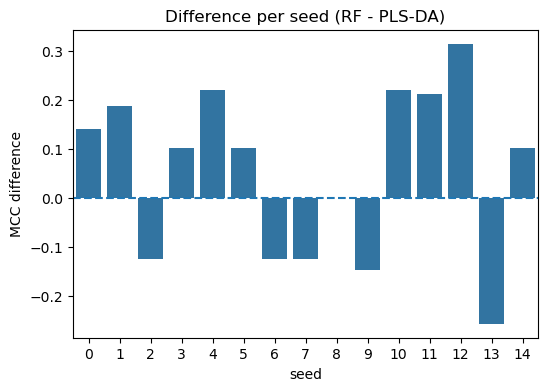

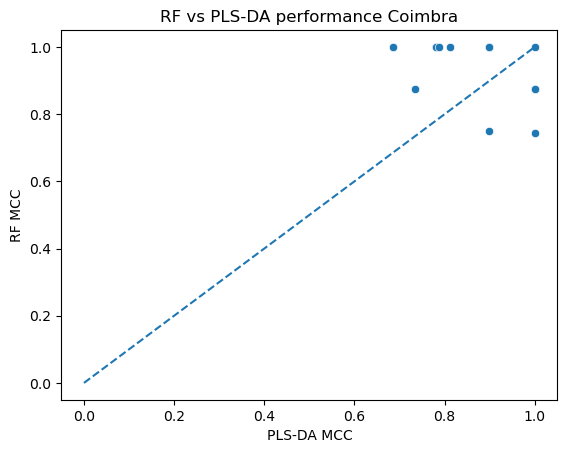

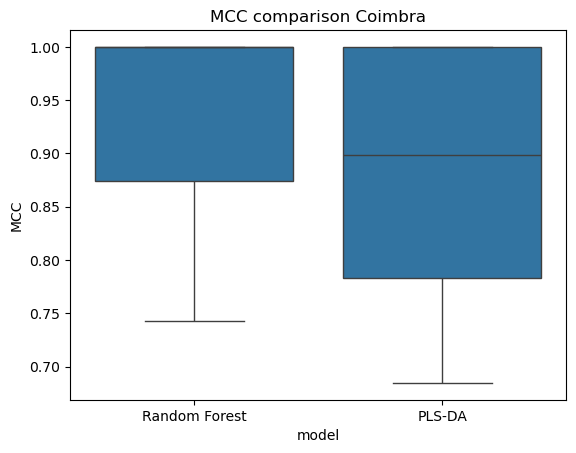

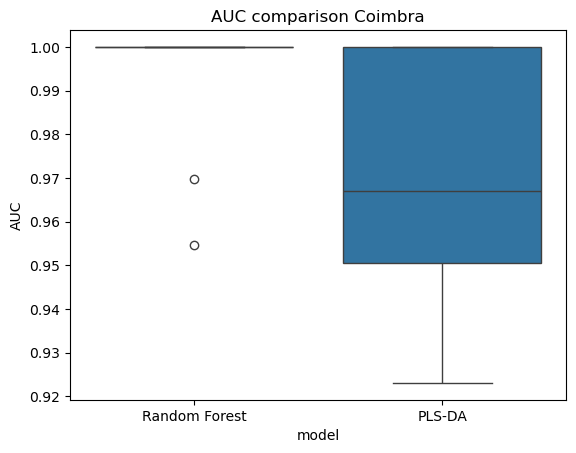

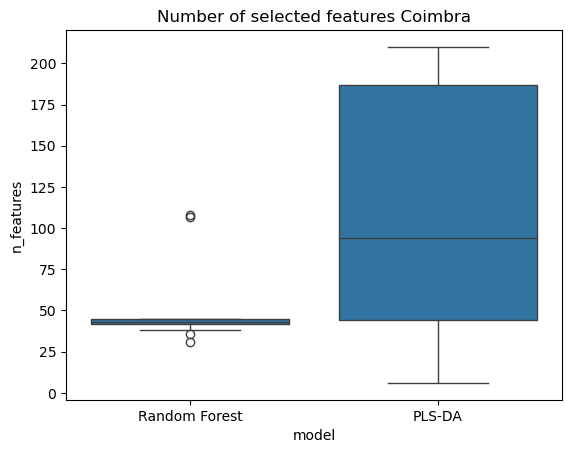

Overlap: 39
Jaccard: 0.639344262295082


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# merge serie
df_merged_Coimbra = pd.concat([global_stability_Coimbra_plsda, global_stability_Coimbra_rf], axis=1)
df_merged_Coimbra.columns = ['freq_plsda', 'freq_rf']

# fill missing
df_merged_Coimbra = df_merged_Coimbra.fillna(0)

plt.figure(figsize=(8,6))

# KDE plot
sns.kdeplot(df_merged_Coimbra['freq_plsda'], label='PLS-DA', fill=True)
sns.kdeplot(df_merged_Coimbra['freq_rf'], label='Random Forest', fill=True)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Distribution of feature selection frequency on Coimbra')

plt.legend()
plt.tight_layout()
plt.savefig('Distribution_of_feature_selection_frequency_Coimbra')
plt.show()

plt.figure(figsize=(8,6))

sns.histplot(df_merged_Coimbra['freq_plsda'], color='blue', label='PLS-DA', kde=True, stat='density', bins=20)
sns.histplot(df_merged_Coimbra['freq_rf'], color='orange', label='Random Forest', kde=True, stat='density', bins=20)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Frequency distribution Coimbra')

plt.legend()
plt.tight_layout()
plt.savefig('Frequency_distribution_Coimbra')
plt.show()


# --- top 50 per ciascun modello ---
top50_plsda = global_stability_Coimbra_plsda.sort_values(ascending=False).head(50)
top50_rf = global_stability_Coimbra_rf.sort_values(ascending=False).head(50)

# --- unione delle proteine ---
proteins_union = set(top50_plsda.index).union(set(top50_rf.index))

# --- costruisci dataframe ---
df_plot = pd.DataFrame({
    'protein': list(proteins_union)
})

# aggiungi frequenze
df_plot['freq_plsda'] = df_plot['protein'].map(global_stability_Coimbra_plsda).fillna(0)
df_plot['freq_rf'] = df_plot['protein'].map(global_stability_Coimbra_rf).fillna(0)

# --- ordina (opzione 1: max frequenza) ---
df_plot['max_freq'] = df_plot[['freq_plsda', 'freq_rf']].max(axis=1)
df_plot = df_plot.sort_values('max_freq', ascending=False)

# --- reshape ---
df_melt = df_plot.melt(
    id_vars='protein',
    value_vars=['freq_plsda', 'freq_rf'],
    var_name='model',
    value_name='frequency'
)

# nomi puliti
df_melt['model'] = df_melt['model'].map({
    'freq_plsda': 'PLS-DA',
    'freq_rf': 'Random Forest'
})

# --- plot ---
plt.figure(figsize=(16,8))

sns.barplot(
    data=df_melt,
    x='protein',
    y='frequency',
    hue='model'
)

plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Selection Frequency')
plt.title('Top 50 PLS-DA vs Top 50 RF (union)')

plt.legend(title='Model')
plt.tight_layout()
plt.show()


df = pd.concat([global_stability_Coimbra_plsda, global_stability_Coimbra_rf], axis=1)
df.columns = ['freq_plsda', 'freq_rf']
df = df.fillna(0)

def categorize(row):
    f_pls = row['freq_plsda']
    f_rf = row['freq_rf']
    
    if f_pls >= 0.5 and f_rf >= 0.5:
        return 'core'
    
    elif (f_pls >= 0.7 and f_rf < 0.3) or (f_rf >= 0.7 and f_pls < 0.3):
        return 'model_specific'
    
    elif f_pls < 0.3 and f_rf < 0.3:
        return 'noise'
    
    else:
        return 'intermediate'

df['category'] = df.apply(categorize, axis=1)
df_extracted_Coimbra = df[(df['category'] == 'intermediate') | (df['category'] == 'core') | (df['category'] == 'model_specific')]

df_compare = pd.merge(
    results_Coimbra_rf_threshold,
    df_plsda,
    on='seed',
    suffixes=('_rf', '_plsda')
)
df_compare['diff_mcc'] = df_compare['mcc_rf'] - df_compare['mcc_plsda']

plt.figure(figsize=(6,4))

sns.barplot(x='seed', y='diff_mcc', data=df_compare)

plt.axhline(0, linestyle='--')
plt.title('Difference per seed (RF - PLS-DA)')
plt.ylabel('MCC difference')

plt.show()


sns.scatterplot(
    x=df_compare['mcc_plsda'],
    y=df_compare['mcc_rf']
)

plt.plot([0,1],[0,1],'--')  # diagonale

plt.xlabel('PLS-DA MCC')
plt.ylabel('RF MCC')
plt.title('RF vs PLS-DA performance Coimbra')
plt.savefig('RF_vs_PLS_DA_performance_Coimbra')
plt.show()



df_mcc = df_compare.melt(
    id_vars='seed',
    value_vars=['mcc_rf', 'mcc_plsda'],
    var_name='model',
    value_name='MCC'
)

df_mcc['model'] = df_mcc['model'].map({
    'mcc_rf': 'Random Forest',
    'mcc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='MCC', data=df_mcc)

plt.title('MCC comparison Coimbra')
plt.savefig('MCC_comparison_Coimbra')
plt.show()


df_auc = df_compare.melt(
    id_vars='seed',
    value_vars=['auc_rf', 'auc_plsda'],
    var_name='model',
    value_name='AUC'
)

df_auc['model'] = df_auc['model'].map({
    'auc_rf': 'Random Forest',
    'auc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='AUC', data=df_auc)

plt.title('AUC comparison Coimbra')
plt.savefig('AUC_comparison_Coimbra')
plt.show()



df_feat = df_compare.melt(
    id_vars='seed',
    value_vars=['n_features_rf', 'n_features_plsda'],
    var_name='model',
    value_name='n_features'
)

df_feat['model'] = df_feat['model'].map({
    'n_features_rf': 'Random Forest',
    'n_features_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='n_features', data=df_feat)

plt.title('Number of selected features Coimbra')
plt.savefig('Number_of_selected_features_Coimbra')
plt.show()


top50_plsda = set(global_stability_Coimbra_plsda.sort_values(ascending=False).head(50).index)
top50_rf = set(global_stability_Coimbra_rf.sort_values(ascending=False).head(50).index)

intersection = top50_plsda.intersection(top50_rf)
union = top50_plsda.union(top50_rf)

jaccard = len(intersection) / len(union)

print("Overlap:", len(intersection))
print("Jaccard:", jaccard)

In [26]:
data = df['category'].value_counts()
data = pd.DataFrame(data)

In [27]:
data

,count
category,
core,56
intermediate,53
noise,48
model_specific,6


In [28]:
results_LC_rf_threshold = pd.read_pickle('results_LC_rf_threshold.pkl')
df_plsda_LC = pd.read_pickle('df_plsda_LC_threshold.pkl')

In [29]:
results_LC_rf_threshold

,seed,mcc,auc,n_features,best_threshold
0,0,0.922600,1.000000,81,0.8
1,1,0.923077,0.980769,122,0.9
2,2,0.761306,0.987179,75,0.8
3,3,0.923077,0.961538,127,0.9
4,4,0.922600,1.000000,78,0.8
5,5,0.849837,1.000000,84,0.8
6,6,0.849837,1.000000,78,0.8
7,7,0.922600,1.000000,48,0.7
8,8,1.000000,1.000000,128,0.9
9,9,1.000000,1.000000,52,0.7


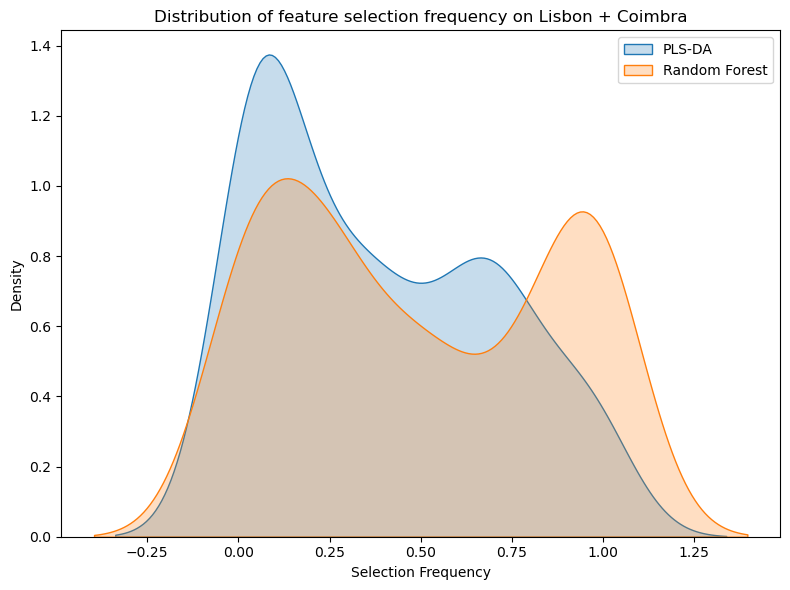

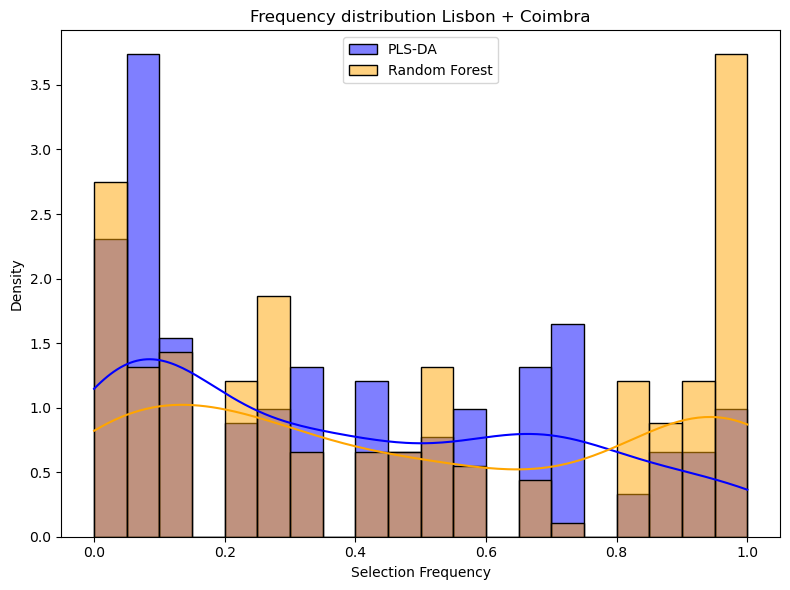

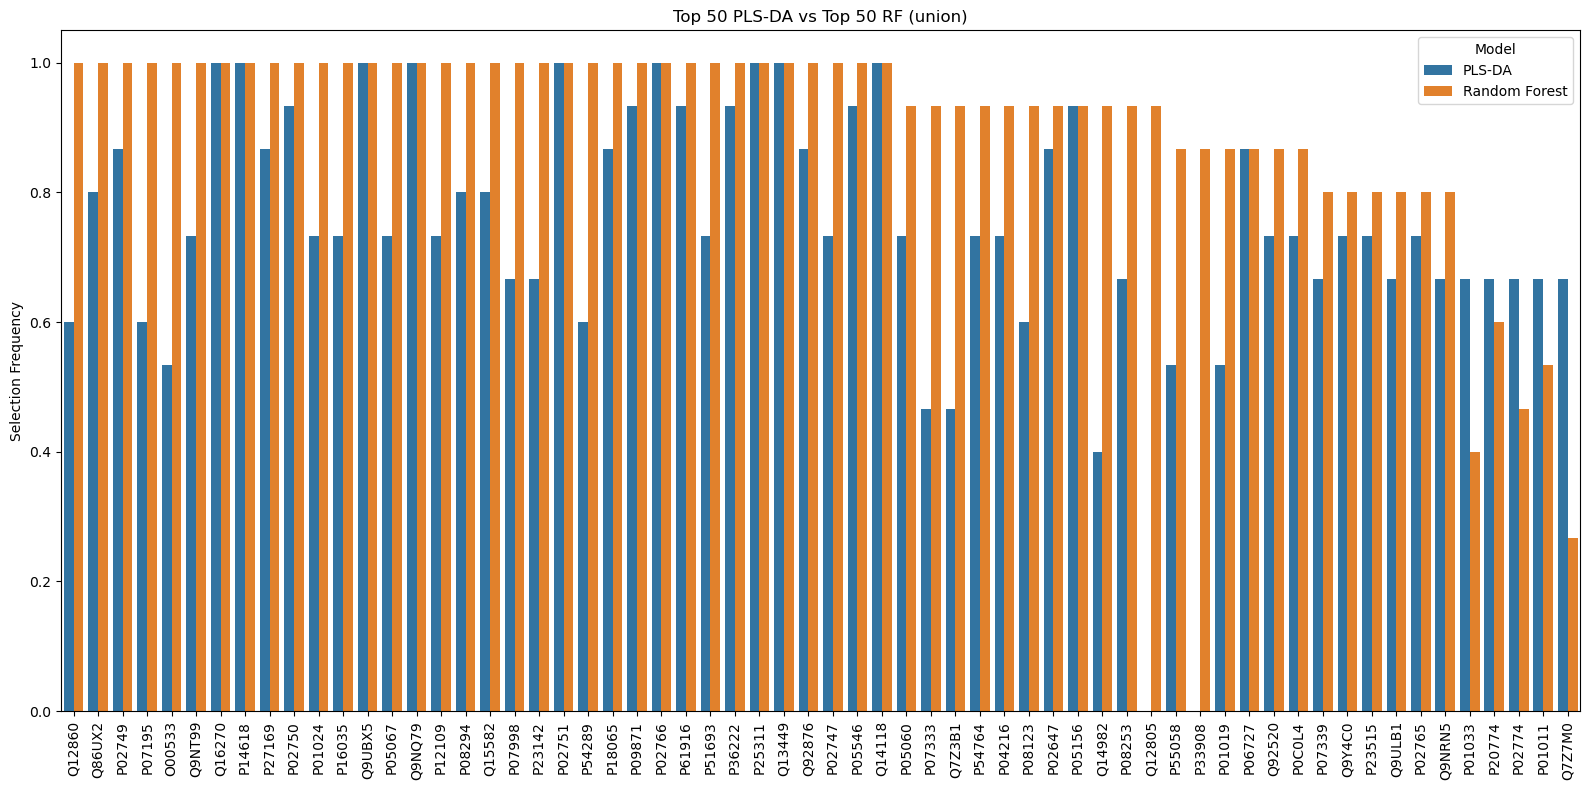

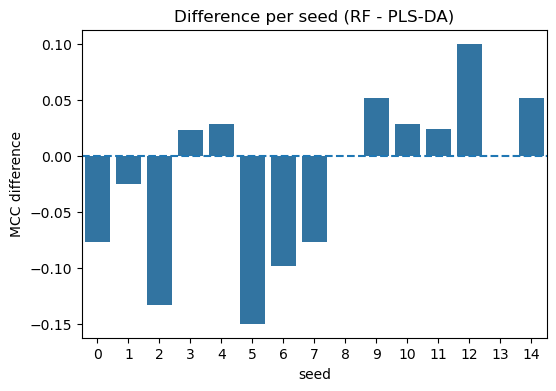

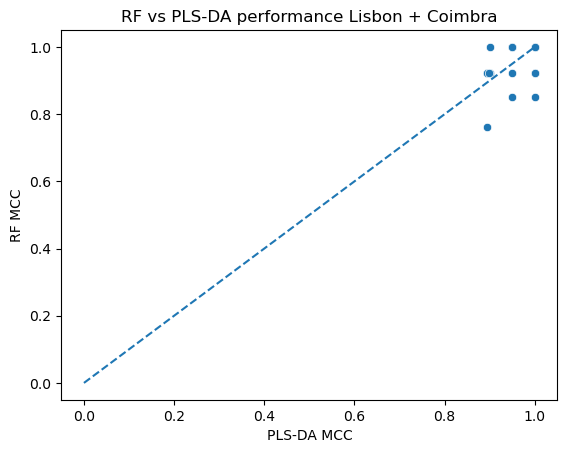

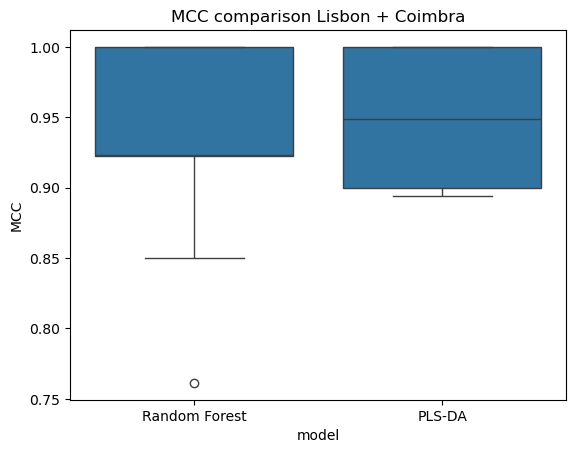

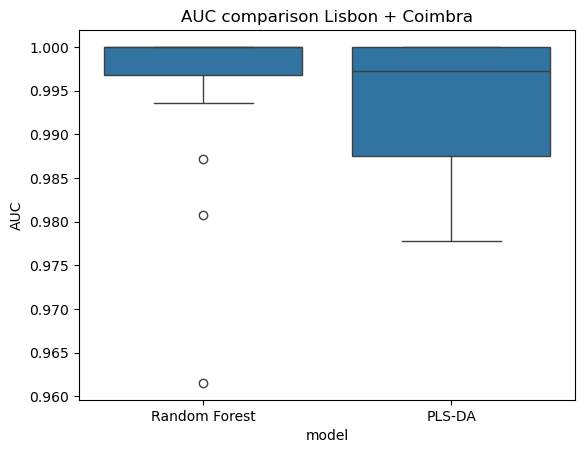

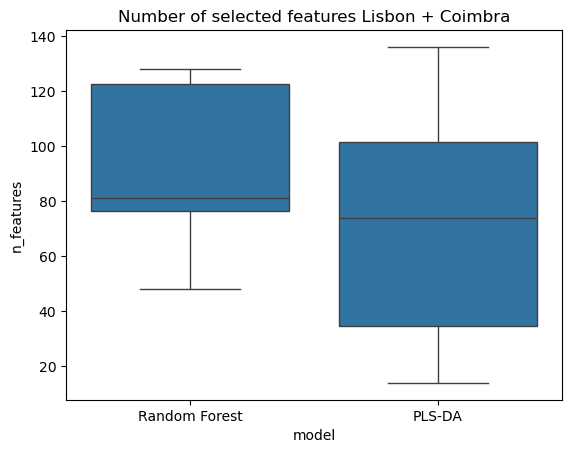

Overlap: 38
Jaccard: 0.6129032258064516


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# merge serie
df_merged_LC = pd.concat([global_stability_LC_plsda, global_stability_LC_rf], axis=1)
df_merged_LC.columns = ['freq_plsda', 'freq_rf']

# fill missing
df_merged_LC = df_merged_LC.fillna(0)

plt.figure(figsize=(8,6))

# KDE plot
sns.kdeplot(df_merged_LC['freq_plsda'], label='PLS-DA', fill=True)
sns.kdeplot(df_merged_LC['freq_rf'], label='Random Forest', fill=True)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Distribution of feature selection frequency on Lisbon + Coimbra')

plt.legend()
plt.tight_layout()
plt.savefig('Distribution_of_feature_selection_frequency_LC')
plt.show()

plt.figure(figsize=(8,6))

sns.histplot(df_merged_LC['freq_plsda'], color='blue', label='PLS-DA', kde=True, stat='density', bins=20)
sns.histplot(df_merged_LC['freq_rf'], color='orange', label='Random Forest', kde=True, stat='density', bins=20)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Frequency distribution Lisbon + Coimbra')

plt.legend()
plt.tight_layout()
plt.savefig('Frequency_distribution_LC')
plt.show()


# --- top 50 per ciascun modello ---
top50_plsda = global_stability_LC_plsda.sort_values(ascending=False).head(50)
top50_rf = global_stability_LC_rf.sort_values(ascending=False).head(50)

# --- unione delle proteine ---
proteins_union = set(top50_plsda.index).union(set(top50_rf.index))

# --- costruisci dataframe ---
df_plot = pd.DataFrame({
    'protein': list(proteins_union)
})

# aggiungi frequenze
df_plot['freq_plsda'] = df_plot['protein'].map(global_stability_LC_plsda).fillna(0)
df_plot['freq_rf'] = df_plot['protein'].map(global_stability_LC_rf).fillna(0)

# --- ordina (opzione 1: max frequenza) ---
df_plot['max_freq'] = df_plot[['freq_plsda', 'freq_rf']].max(axis=1)
df_plot = df_plot.sort_values('max_freq', ascending=False)

# --- reshape ---
df_melt = df_plot.melt(
    id_vars='protein',
    value_vars=['freq_plsda', 'freq_rf'],
    var_name='model',
    value_name='frequency'
)

# nomi puliti
df_melt['model'] = df_melt['model'].map({
    'freq_plsda': 'PLS-DA',
    'freq_rf': 'Random Forest'
})

# --- plot ---
plt.figure(figsize=(16,8))

sns.barplot(
    data=df_melt,
    x='protein',
    y='frequency',
    hue='model'
)

plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Selection Frequency')
plt.title('Top 50 PLS-DA vs Top 50 RF (union)')

plt.legend(title='Model')
plt.tight_layout()
plt.show()


df = pd.concat([global_stability_LC_plsda, global_stability_LC_rf], axis=1)
df.columns = ['freq_plsda', 'freq_rf']
df = df.fillna(0)

def categorize(row):
    f_pls = row['freq_plsda']
    f_rf = row['freq_rf']
    
    if f_pls >= 0.5 and f_rf >= 0.5:
        return 'core'
    
    elif (f_pls >= 0.7 and f_rf < 0.3) or (f_rf >= 0.7 and f_pls < 0.3):
        return 'model_specific'
    
    elif f_pls < 0.3 and f_rf < 0.3:
        return 'noise'
    
    else:
        return 'intermediate'

df['category'] = df.apply(categorize, axis=1)
df_extracted_LC = df[(df['category'] == 'intermediate') | (df['category'] == 'core') | (df['category'] == 'model_specific')]

df_compare = pd.merge(
    results_LC_rf_threshold,
    df_plsda_LC,
    on='seed',
    suffixes=('_rf', '_plsda')
)
df_compare['diff_mcc'] = df_compare['mcc_rf'] - df_compare['mcc_plsda']




plt.figure(figsize=(6,4))

sns.barplot(x='seed', y='diff_mcc', data=df_compare)

plt.axhline(0, linestyle='--')
plt.title('Difference per seed (RF - PLS-DA)')
plt.ylabel('MCC difference')

plt.show()


sns.scatterplot(
    x=df_compare['mcc_plsda'],
    y=df_compare['mcc_rf']
)

plt.plot([0,1],[0,1],'--')  # diagonale

plt.xlabel('PLS-DA MCC')
plt.ylabel('RF MCC')
plt.title('RF vs PLS-DA performance Lisbon + Coimbra')
plt.savefig('RF_vs_PLS_DA_performance_LC')
plt.show()



df_mcc = df_compare.melt(
    id_vars='seed',
    value_vars=['mcc_rf', 'mcc_plsda'],
    var_name='model',
    value_name='MCC'
)

df_mcc['model'] = df_mcc['model'].map({
    'mcc_rf': 'Random Forest',
    'mcc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='MCC', data=df_mcc)

plt.title('MCC comparison Lisbon + Coimbra')
plt.savefig('MCC_comparison_LC')
plt.show()


df_auc = df_compare.melt(
    id_vars='seed',
    value_vars=['auc_rf', 'auc_plsda'],
    var_name='model',
    value_name='AUC'
)

df_auc['model'] = df_auc['model'].map({
    'auc_rf': 'Random Forest',
    'auc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='AUC', data=df_auc)

plt.title('AUC comparison Lisbon + Coimbra')
plt.savefig('AUC_comparison_LC')
plt.show()



df_feat = df_compare.melt(
    id_vars='seed',
    value_vars=['n_features_rf', 'n_features_plsda'],
    var_name='model',
    value_name='n_features'
)

df_feat['model'] = df_feat['model'].map({
    'n_features_rf': 'Random Forest',
    'n_features_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='n_features', data=df_feat)

plt.title('Number of selected features Lisbon + Coimbra')
plt.savefig('Number_of_selected_features_LC')
plt.show()



top50_plsda = set(global_stability_LC_plsda.sort_values(ascending=False).head(50).index)
top50_rf = set(global_stability_LC_rf.sort_values(ascending=False).head(50).index)

intersection = top50_plsda.intersection(top50_rf)
union = top50_plsda.union(top50_rf)

jaccard = len(intersection) / len(union)

print("Overlap:", len(intersection))
print("Jaccard:", jaccard)

In [31]:
data = df['category'].value_counts()
data = pd.DataFrame(data)

In [32]:
data

,count
category,
noise,68
core,61
intermediate,50
model_specific,3


In [33]:
results_ConL_rf_threshold = pd.read_pickle('results_CoimbraonLisbon_rf_threshold.pkl')
global_stability_coimbraonlisbon_plsda = global_stability_coimbraonlisbon_plsda/15
df_plsda_ConL = pd.read_pickle('df_plsda_coimbraonlisbon_threshold.pkl')

In [34]:
results_ConL_rf_threshold

,model,seed,mcc,auc,n_features,threshold
0,RF,0,0.380334,0.724155,33,0.7
1,RF,1,0.380334,0.775845,49,0.8
2,RF,2,0.380334,0.727053,34,0.7
3,RF,3,0.364020,0.717874,49,0.8
4,RF,4,0.380334,0.693237,51,0.8
5,RF,5,0.396566,0.737681,33,0.7
6,RF,6,0.380334,0.748792,50,0.8
7,RF,7,0.380334,0.691787,49,0.8
8,RF,8,0.364020,0.798068,83,0.9
9,RF,9,0.380334,0.752174,50,0.8


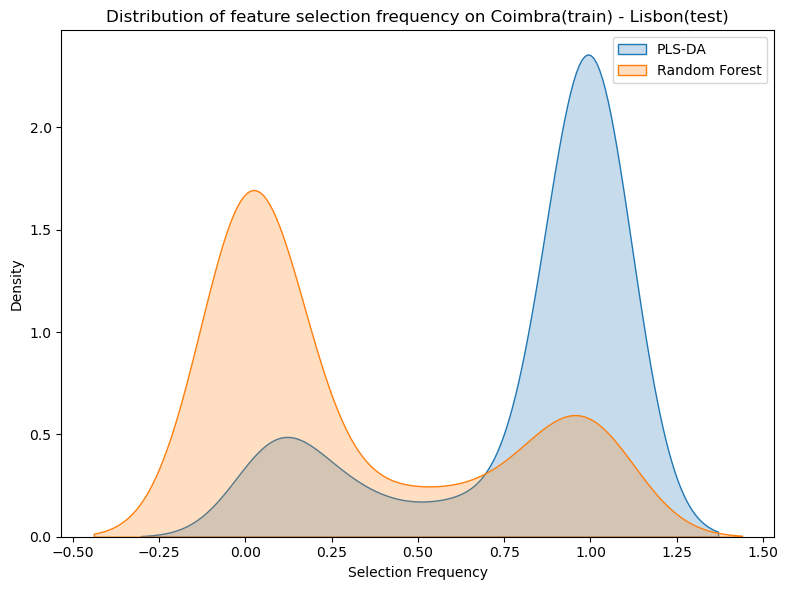

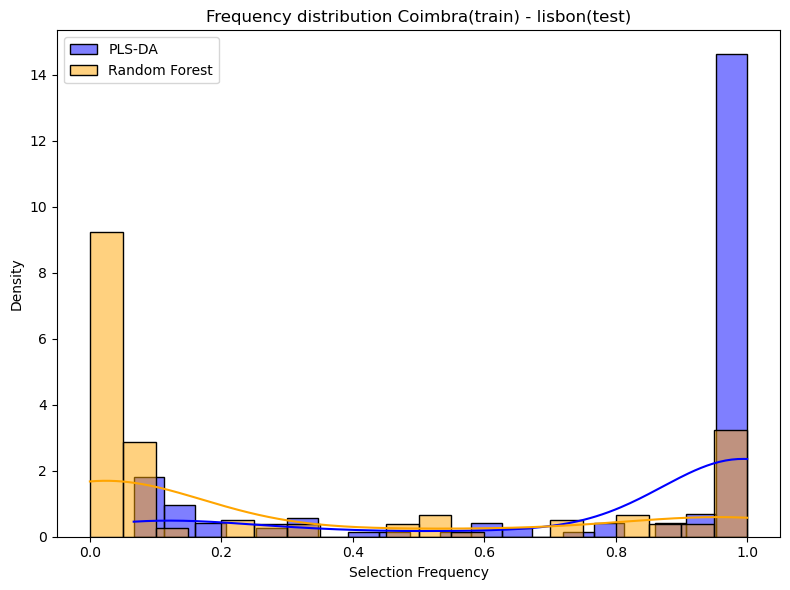

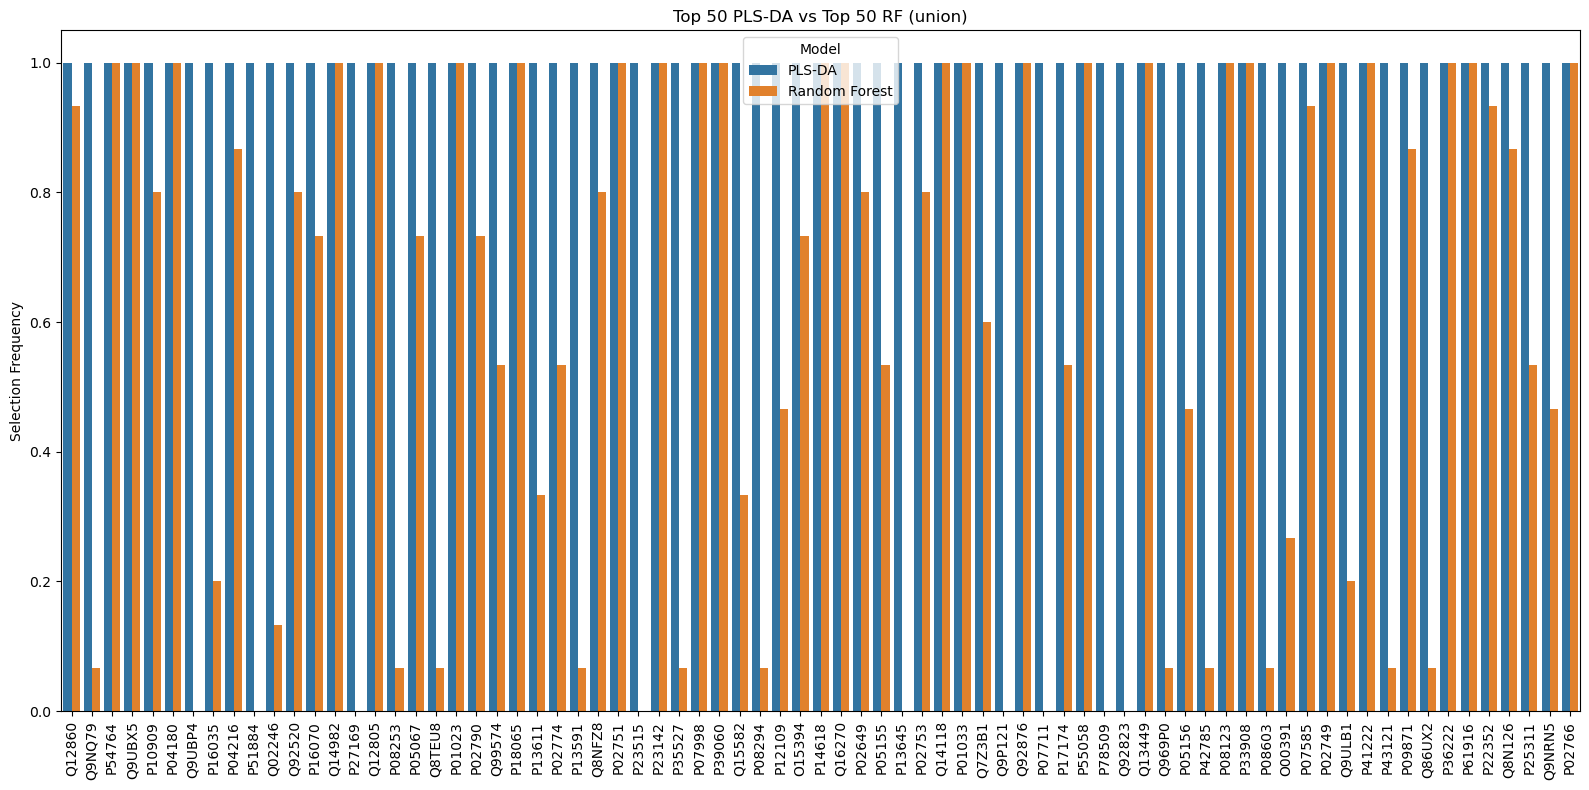

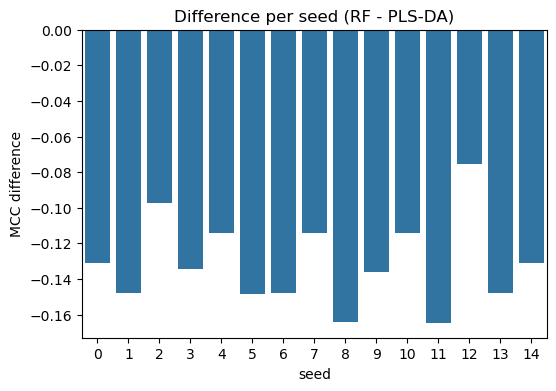

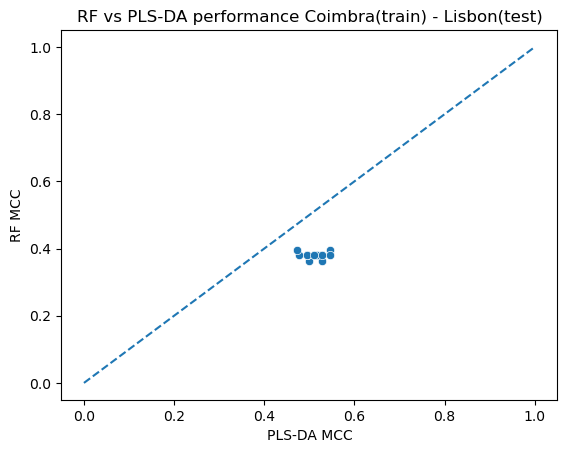

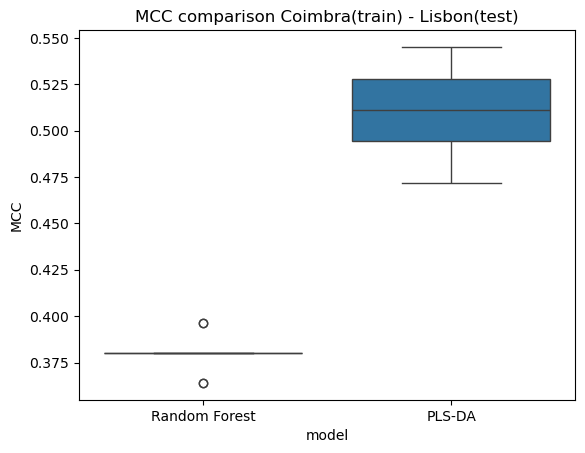

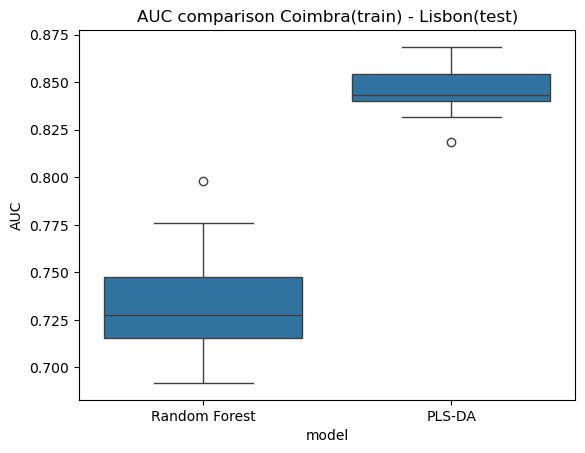

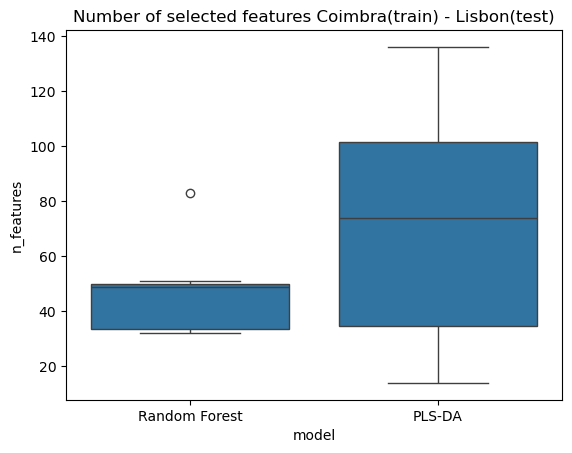

Overlap: 25
Jaccard: 0.3333333333333333


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# merge serie
df_merged_coimbraonlisbon = pd.concat([global_stability_coimbraonlisbon_plsda, global_stability_CoimbraonLisbon_rf], axis=1)
df_merged_coimbraonlisbon.columns = ['freq_plsda', 'freq_rf']

# fill missing
df_merged_coimbraonlisbon = df_merged_coimbraonlisbon.fillna(0)

plt.figure(figsize=(8,6))

# KDE plot
sns.kdeplot(df_merged_coimbraonlisbon['freq_plsda'], label='PLS-DA', fill=True)
sns.kdeplot(df_merged_coimbraonlisbon['freq_rf'], label='Random Forest', fill=True)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Distribution of feature selection frequency on Coimbra(train) - Lisbon(test)')

plt.legend()
plt.tight_layout()
plt.savefig('Distribution_of_feature_selection_frequency_CoimbraonLisbon')
plt.show()

plt.figure(figsize=(8,6))

sns.histplot(df_merged_coimbraonlisbon['freq_plsda'], color='blue', label='PLS-DA', kde=True, stat='density', bins=20)
sns.histplot(df_merged_coimbraonlisbon['freq_rf'], color='orange', label='Random Forest', kde=True, stat='density', bins=20)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Frequency distribution Coimbra(train) - lisbon(test)')

plt.legend()
plt.tight_layout()
plt.savefig('Frequency_distribution_coimbraonlisbon')
plt.show()


# --- top 50 per ciascun modello ---
top50_plsda = global_stability_coimbraonlisbon_plsda.sort_values(ascending=False).head(50)
top50_rf = global_stability_CoimbraonLisbon_rf.sort_values(ascending=False).head(50)

# --- unione delle proteine ---
proteins_union = set(top50_plsda.index).union(set(top50_rf.index))

# --- costruisci dataframe ---
df_plot = pd.DataFrame({
    'protein': list(proteins_union)
})

# aggiungi frequenze
df_plot['freq_plsda'] = df_plot['protein'].map(global_stability_coimbraonlisbon_plsda).fillna(0)
df_plot['freq_rf'] = df_plot['protein'].map(global_stability_CoimbraonLisbon_rf).fillna(0)

# --- ordina (opzione 1: max frequenza) ---
df_plot['max_freq'] = df_plot[['freq_plsda', 'freq_rf']].max(axis=1)
df_plot = df_plot.sort_values('max_freq', ascending=False)

# --- reshape ---
df_melt = df_plot.melt(
    id_vars='protein',
    value_vars=['freq_plsda', 'freq_rf'],
    var_name='model',
    value_name='frequency'
)

# nomi puliti
df_melt['model'] = df_melt['model'].map({
    'freq_plsda': 'PLS-DA',
    'freq_rf': 'Random Forest'
})

# --- plot ---
plt.figure(figsize=(16,8))

sns.barplot(
    data=df_melt,
    x='protein',
    y='frequency',
    hue='model'
)

plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Selection Frequency')
plt.title('Top 50 PLS-DA vs Top 50 RF (union)')

plt.legend(title='Model')
plt.tight_layout()
plt.show()


df = pd.concat([global_stability_coimbraonlisbon_plsda, global_stability_CoimbraonLisbon_rf], axis=1)
df.columns = ['freq_plsda', 'freq_rf']
df = df.fillna(0)

def categorize(row):
    f_pls = row['freq_plsda']
    f_rf = row['freq_rf']
    
    if f_pls >= 0.5 and f_rf >= 0.5:
        return 'core'
    
    elif (f_pls >= 0.7 and f_rf < 0.3) or (f_rf >= 0.7 and f_pls < 0.3):
        return 'model_specific'
    
    elif f_pls < 0.3 and f_rf < 0.3:
        return 'noise'
    
    else:
        return 'intermediate'

df['category'] = df.apply(categorize, axis=1)


df_compare = pd.merge(
    results_ConL_rf_threshold,
    df_plsda_ConL,
    on='seed',
    suffixes=('_rf', '_plsda')
)
df_compare['diff_mcc'] = df_compare['mcc_rf'] - df_compare['mcc_plsda']




plt.figure(figsize=(6,4))

sns.barplot(x='seed', y='diff_mcc', data=df_compare)

plt.axhline(0, linestyle='--')
plt.title('Difference per seed (RF - PLS-DA)')
plt.ylabel('MCC difference')

plt.show()


sns.scatterplot(
    x=df_compare['mcc_plsda'],
    y=df_compare['mcc_rf']
)

plt.plot([0,1],[0,1],'--')  # diagonale

plt.xlabel('PLS-DA MCC')
plt.ylabel('RF MCC')
plt.title('RF vs PLS-DA performance Coimbra(train) - Lisbon(test)')
plt.savefig('RF_vs_PLS_DA_performance_coimbraonlisbon')
plt.show()



df_mcc = df_compare.melt(
    id_vars='seed',
    value_vars=['mcc_rf', 'mcc_plsda'],
    var_name='model',
    value_name='MCC'
)

df_mcc['model'] = df_mcc['model'].map({
    'mcc_rf': 'Random Forest',
    'mcc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='MCC', data=df_mcc)

plt.title('MCC comparison Coimbra(train) - Lisbon(test)')
plt.savefig('MCC_comparison_coimbraoonlisbon')
plt.show()


df_auc = df_compare.melt(
    id_vars='seed',
    value_vars=['auc_rf', 'auc_plsda'],
    var_name='model',
    value_name='AUC'
)

df_auc['model'] = df_auc['model'].map({
    'auc_rf': 'Random Forest',
    'auc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='AUC', data=df_auc)

plt.title('AUC comparison Coimbra(train) - Lisbon(test)')
plt.savefig('AUC_comparison_coimbraoonlisbon')
plt.show()



df_feat = df_compare.melt(
    id_vars='seed',
    value_vars=['n_features_rf', 'n_features_plsda'],
    var_name='model',
    value_name='n_features'
)

df_feat['model'] = df_feat['model'].map({
    'n_features_rf': 'Random Forest',
    'n_features_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='n_features', data=df_feat)

plt.title('Number of selected features Coimbra(train) - Lisbon(test)')
plt.savefig('Number_of_selected_features_coimbraoonlisbon')
plt.show()


top50_plsda = set(global_stability_coimbraonlisbon_plsda.sort_values(ascending=False).head(50).index)
top50_rf = set(global_stability_CoimbraonLisbon_rf.sort_values(ascending=False).head(50).index)

intersection = top50_plsda.intersection(top50_rf)
union = top50_plsda.union(top50_rf)

jaccard = len(intersection) / len(union)

print("Overlap:", len(intersection))
print("Jaccard:", jaccard)

In [36]:
data = df['category'].value_counts()
data = pd.DataFrame(data)

In [37]:
data

,count
category,
model_specific,65
core,46
noise,25
intermediate,18


In [38]:
results_LonC_rf_threshold = pd.read_pickle('results_LisbononCoimbra_rf_threshold.pkl')
df_plsda_LonC = pd.read_pickle('df_plsda_LisbononCoimbra_threshold.pkl')

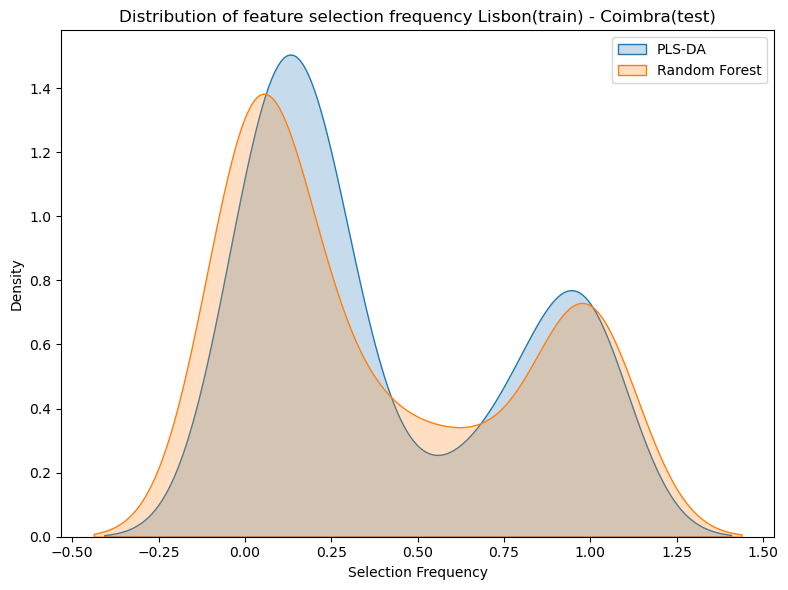

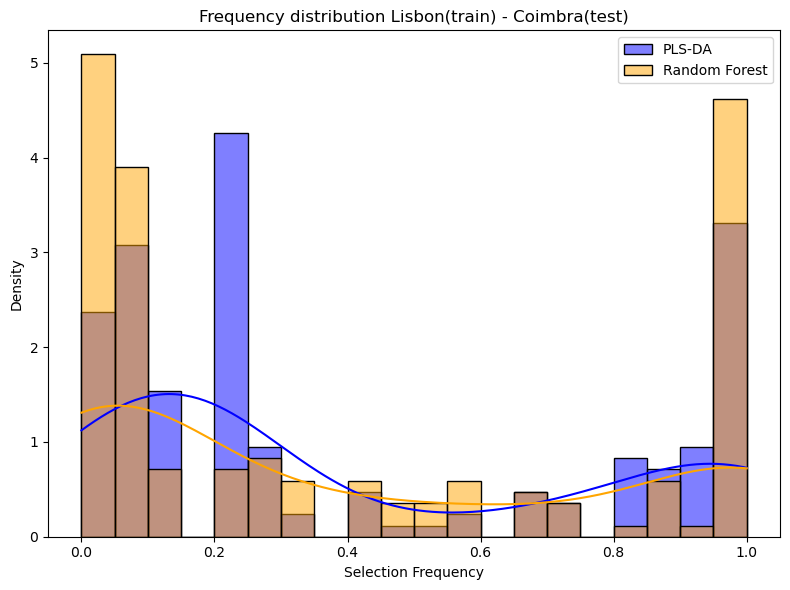

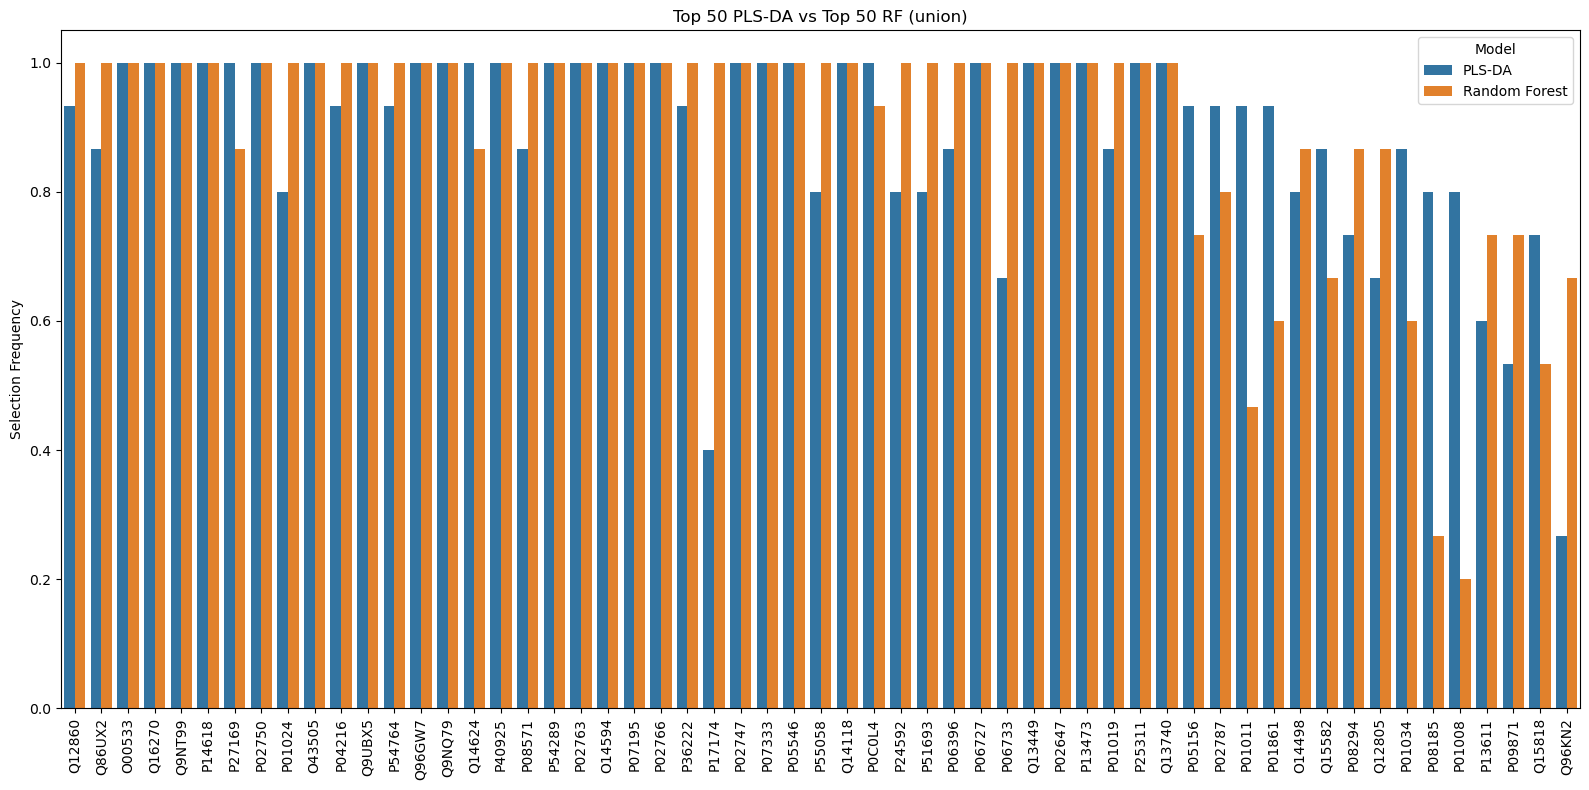

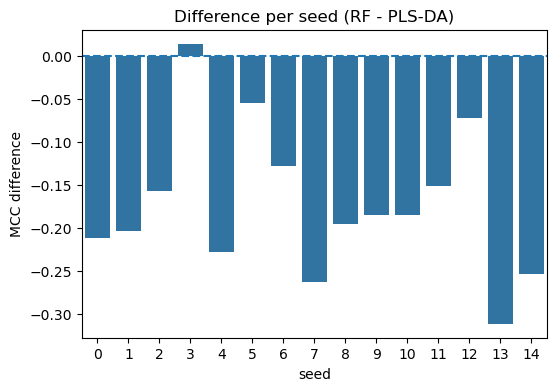

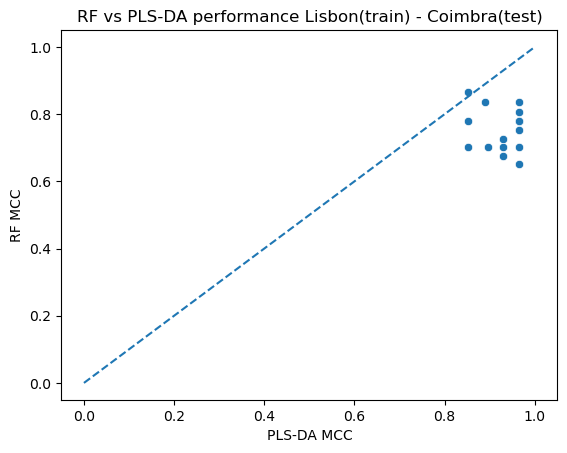

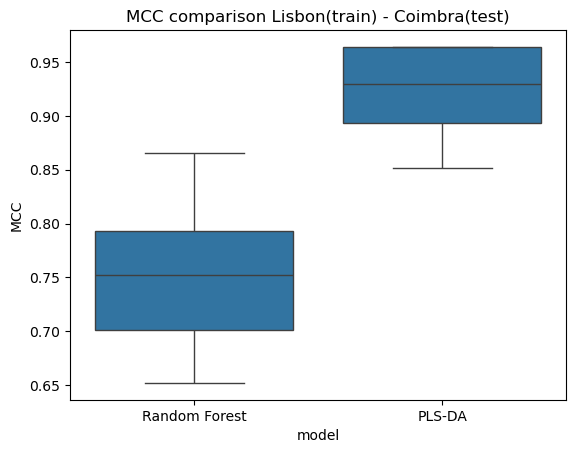

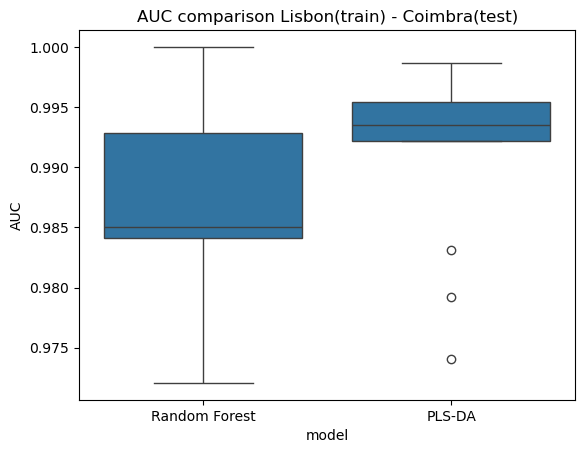

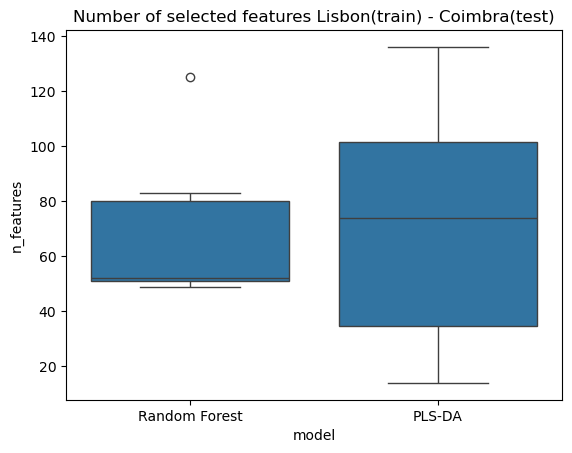

Overlap: 43
Jaccard: 0.7543859649122807


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# merge serie
df_merged_LisbononCoimbra = pd.concat([global_stability_LisbononCoimbra_plsda, global_stability_LisbononCoimbra_rf], axis=1)
df_merged_LisbononCoimbra.columns = ['freq_plsda', 'freq_rf']

# fill missing
df_merged_LisbononCoimbra = df_merged_LisbononCoimbra.fillna(0)

plt.figure(figsize=(8,6))

# KDE plot
sns.kdeplot(df_merged_LisbononCoimbra['freq_plsda'], label='PLS-DA', fill=True)
sns.kdeplot(df_merged_LisbononCoimbra['freq_rf'], label='Random Forest', fill=True)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Distribution of feature selection frequency Lisbon(train) - Coimbra(test)')

plt.legend()
plt.tight_layout()
plt.savefig('Distribution_of_feature_selection_frequency_LisbononCoimbra')
plt.show()

plt.figure(figsize=(8,6))

sns.histplot(df_merged_LisbononCoimbra['freq_plsda'], color='blue', label='PLS-DA', kde=True, stat='density', bins=20)
sns.histplot(df_merged_LisbononCoimbra['freq_rf'], color='orange', label='Random Forest', kde=True, stat='density', bins=20)

plt.xlabel('Selection Frequency')
plt.ylabel('Density')
plt.title('Frequency distribution Lisbon(train) - Coimbra(test)')

plt.legend()
plt.tight_layout()
plt.savefig('Frequency_distribution_LisbononCoimbra')
plt.show()


# --- top 50 per ciascun modello ---
top50_plsda = global_stability_LisbononCoimbra_plsda.sort_values(ascending=False).head(50)
top50_rf = global_stability_LisbononCoimbra_rf.sort_values(ascending=False).head(50)

# --- unione delle proteine ---
proteins_union = set(top50_plsda.index).union(set(top50_rf.index))

# --- costruisci dataframe ---
df_plot = pd.DataFrame({
    'protein': list(proteins_union)
})

# aggiungi frequenze
df_plot['freq_plsda'] = df_plot['protein'].map(global_stability_LisbononCoimbra_plsda).fillna(0)
df_plot['freq_rf'] = df_plot['protein'].map(global_stability_LisbononCoimbra_rf).fillna(0)

# --- ordina (opzione 1: max frequenza) ---
df_plot['max_freq'] = df_plot[['freq_plsda', 'freq_rf']].max(axis=1)
df_plot = df_plot.sort_values('max_freq', ascending=False)

# --- reshape ---
df_melt = df_plot.melt(
    id_vars='protein',
    value_vars=['freq_plsda', 'freq_rf'],
    var_name='model',
    value_name='frequency'
)

# nomi puliti
df_melt['model'] = df_melt['model'].map({
    'freq_plsda': 'PLS-DA',
    'freq_rf': 'Random Forest'
})

# --- plot ---
plt.figure(figsize=(16,8))

sns.barplot(
    data=df_melt,
    x='protein',
    y='frequency',
    hue='model'
)

plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Selection Frequency')
plt.title('Top 50 PLS-DA vs Top 50 RF (union)')

plt.legend(title='Model')
plt.tight_layout()
plt.show()


df = pd.concat([global_stability_LisbononCoimbra_plsda, global_stability_LisbononCoimbra_rf], axis=1)
df.columns = ['freq_plsda', 'freq_rf']
df = df.fillna(0)

def categorize(row):
    f_pls = row['freq_plsda']
    f_rf = row['freq_rf']
    
    if f_pls >= 0.5 and f_rf >= 0.5:
        return 'core'
    
    elif (f_pls >= 0.7 and f_rf < 0.3) or (f_rf >= 0.7 and f_pls < 0.3):
        return 'model_specific'
    
    elif f_pls < 0.3 and f_rf < 0.3:
        return 'noise'
    
    else:
        return 'intermediate'

df['category'] = df.apply(categorize, axis=1)


df_compare = pd.merge(
    results_LonC_rf_threshold,
    df_plsda_LonC,
    on='seed',
    suffixes=('_rf', '_plsda')
)
df_compare['diff_mcc'] = df_compare['mcc_rf'] - df_compare['mcc_plsda']




plt.figure(figsize=(6,4))

sns.barplot(x='seed', y='diff_mcc', data=df_compare)

plt.axhline(0, linestyle='--')
plt.title('Difference per seed (RF - PLS-DA)')
plt.ylabel('MCC difference')

plt.show()


sns.scatterplot(
    x=df_compare['mcc_plsda'],
    y=df_compare['mcc_rf']
)

plt.plot([0,1],[0,1],'--')  # diagonale

plt.xlabel('PLS-DA MCC')
plt.ylabel('RF MCC')
plt.title('RF vs PLS-DA performance Lisbon(train) - Coimbra(test)')
plt.savefig('RF_vs_PLS_DA_performance_lisbononcoimbra')
plt.show()



df_mcc = df_compare.melt(
    id_vars='seed',
    value_vars=['mcc_rf', 'mcc_plsda'],
    var_name='model',
    value_name='MCC'
)

df_mcc['model'] = df_mcc['model'].map({
    'mcc_rf': 'Random Forest',
    'mcc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='MCC', data=df_mcc)

plt.title('MCC comparison Lisbon(train) - Coimbra(test)')
plt.savefig('MCC_comparison_lisbononcoimbra')
plt.show()


df_auc = df_compare.melt(
    id_vars='seed',
    value_vars=['auc_rf', 'auc_plsda'],
    var_name='model',
    value_name='AUC'
)

df_auc['model'] = df_auc['model'].map({
    'auc_rf': 'Random Forest',
    'auc_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='AUC', data=df_auc)

plt.title('AUC comparison Lisbon(train) - Coimbra(test)')
plt.savefig('AUC_comparison_lisbononcoimbra')
plt.show()



df_feat = df_compare.melt(
    id_vars='seed',
    value_vars=['n_features_rf', 'n_features_plsda'],
    var_name='model',
    value_name='n_features'
)

df_feat['model'] = df_feat['model'].map({
    'n_features_rf': 'Random Forest',
    'n_features_plsda': 'PLS-DA'
})

sns.boxplot(x='model', y='n_features', data=df_feat)

plt.title('Number of selected features Lisbon(train) - Coimbra(test)')
plt.savefig('Number_of_selected_features_lisbononcoimbra')
plt.show()


top50_plsda = set(global_stability_LisbononCoimbra_plsda.sort_values(ascending=False).head(50).index)
top50_rf = set(global_stability_LisbononCoimbra_rf.sort_values(ascending=False).head(50).index)

intersection = top50_plsda.intersection(top50_rf)
union = top50_plsda.union(top50_rf)

jaccard = len(intersection) / len(union)

print("Overlap:", len(intersection))
print("Jaccard:", jaccard)

In [40]:
data = df['category'].value_counts()
data = pd.DataFrame(data)

In [41]:
prot_Coimbra = df_extracted_Coimbra.index
prot_Lisbon = df_extracted_Lisbon.index
prot_LC = df_extracted_LC.index

In [42]:
import pickle

with open('prot_Coimbra.pkl', 'wb') as f:
    pickle.dump(prot_Coimbra, f)
with open('prot_Lisbon.pkl', 'wb') as f:
    pickle.dump(prot_Lisbon, f)
with open('prot_LC.pkl', 'wb') as f:
    pickle.dump(prot_LC, f)

In [43]:
df_extracted_Lisbon

,freq_plsda,freq_rf,category
P40925,1.000000,1.000000,core
P14618,1.000000,1.000000,core
P07195,1.000000,1.000000,core
Q13449,1.000000,1.000000,core
P02750,0.933333,1.000000,core
...,...,...,...
P01009,0.333333,0.000000,intermediate
P00747,0.333333,0.066667,intermediate
P06312,0.266667,0.466667,intermediate
Q99574,0.200000,0.600000,intermediate


In [44]:
df_extracted_LC

,freq_plsda,freq_rf,category
Q16270,1.0,1.000000,core
P02751,1.0,1.000000,core
P02766,1.0,1.000000,core
P14618,1.0,1.000000,core
Q9UBX5,1.0,1.000000,core
...,...,...,...
Q12805,0.0,0.933333,model_specific
P33908,0.0,0.866667,model_specific
P41222,0.0,0.466667,intermediate
P08571,0.0,0.400000,intermediate


In [45]:
vip_global_series_Coimbra_threshold = pd.read_pickle('vip_global_series_Coimbra_threshold.pkl')
print(len(vip_global_series_Coimbra_threshold))
vip_global_series_LC_threshold = pd.read_pickle('vip_global_series_LC_threshold.pkl')
print(len(vip_global_series_LC_threshold))
vip_global_series_Lisbon_threshold = pd.read_pickle('vip_global_series_Lisbon_threshold.pkl')
print(len(vip_global_series_Lisbon_threshold))
feature_2_rf_Coimbra_threshold = pd.read_pickle('feature_2_rf_Coimbra_threshold.pkl')
print(len(feature_2_rf_Coimbra_threshold))
feature_2_rf_LC_threshold = pd.read_pickle('feature_2_rf_LC_threshold.pkl')
print(len(feature_2_rf_LC_threshold))
feature_2_rf_Lisbon_threshold = pd.read_pickle('feature_2_rf_Lisbon_threshold.pkl')
print(len(feature_2_rf_Lisbon_threshold))

237
201
255
237
201
255


In [46]:
vip_global_series_Coimbra_threshold = vip_global_series_Coimbra_threshold[vip_global_series_Coimbra_threshold > 0]
vip_global_series_Lisbon_threshold = vip_global_series_Lisbon_threshold[vip_global_series_Lisbon_threshold > 0]
vip_global_series_LC_threshold = vip_global_series_LC_threshold[vip_global_series_LC_threshold > 0]
feature_2_rf_Coimbra_threshold = feature_2_rf_Coimbra_threshold[feature_2_rf_Coimbra_threshold > 0]
feature_2_rf_LC_threshold = feature_2_rf_LC_threshold[feature_2_rf_LC_threshold > 0]
print(len(vip_global_series_Coimbra_threshold))
print(len(vip_global_series_Lisbon_threshold))
print(len(vip_global_series_LC_threshold))
print(len(feature_2_rf_Coimbra_threshold))
print(len(feature_2_rf_LC_threshold))
feature_2_rf_Lisbon_threshold = feature_2_rf_Lisbon_threshold[feature_2_rf_Lisbon_threshold > 0]
print(len(feature_2_rf_Lisbon_threshold))

237
255
201
68
115
170


In [47]:
datasets = {
    "Coimbra": {
        "pls": vip_global_series_Coimbra_threshold,
        "rf": feature_2_rf_Coimbra_threshold
    },
    "Lisbon": {
        "pls": vip_global_series_Lisbon_threshold,
        "rf": feature_2_rf_Lisbon_threshold
    },
    "LC": {
        "pls": vip_global_series_LC_threshold,
        "rf": feature_2_rf_LC_threshold
    }
}
def categorize(row):
    f_pls = row['freq_plsda']
    f_rf = row['freq_rf']
    
    if f_pls >= 0.5 and f_rf >= 0.5:
        return 'core'
    
    elif (f_pls >= 0.7 and f_rf < 0.3) or (f_rf >= 0.7 and f_pls < 0.3):
        return 'model_specific'
    
    elif f_pls < 0.3 and f_rf < 0.3:
        return 'noise'
    
    else:
        return 'intermediate'
results = {}

for name, data in datasets.items():
    
    pls = data["pls"]
    rf = data["rf"]
    
    # unione
    df = pd.concat([pls, rf], axis=1)
    df.columns = ['freq_plsda', 'freq_rf']
    df = df.fillna(0)
    
    # categorizzazione
    df['category'] = df.apply(categorize, axis=1)
    
    results[name] = df
    
    print(f"\n===== {name} =====")
    print(df['category'].value_counts())


===== Coimbra =====
category
noise             133
intermediate       54
core               38
model_specific     12
Name: count, dtype: int64

===== Lisbon =====
category
noise             106
intermediate       80
core               66
model_specific      3
Name: count, dtype: int64

===== LC =====
category
noise             102
core               56
intermediate       35
model_specific      8
Name: count, dtype: int64


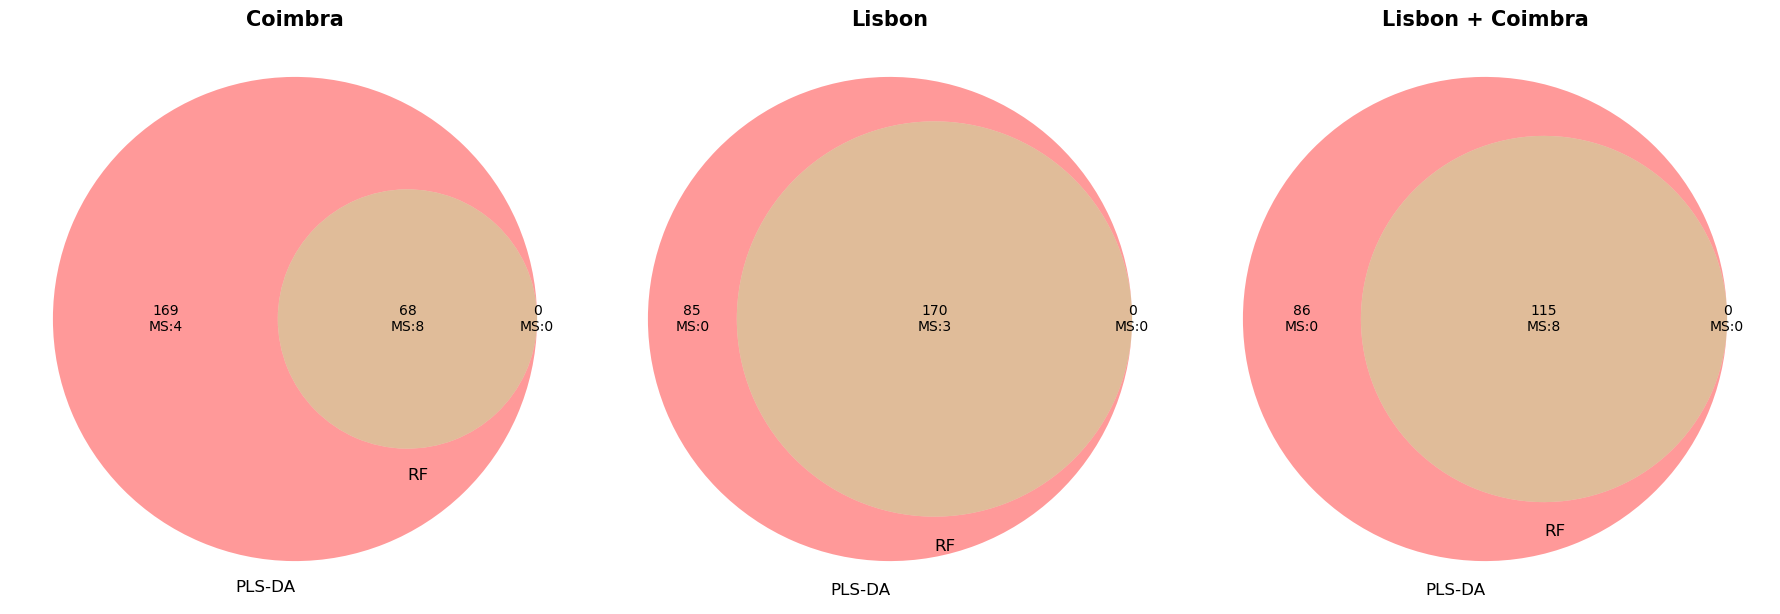

In [48]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

def plot_combined_venn(results_dict):
    # Creiamo una figura con 3 sottografici (1 riga, 3 colonne)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Mappiamo i titoli ai tasti del tuo dizionario
    datasets = [("Coimbra", "Coimbra"), ("Lisbon", "Lisbon"), ("LC", "Lisbon + Coimbra")]

    for ax, (key, title) in zip(axes, datasets):
        df = results_dict[key]
        
        # Definizione dei set
        set_pls = set(df[df['freq_plsda'] > 0].index)
        set_rf = set(df[df['freq_rf'] > 0].index)
        ms = set(df[df['category'] == 'model_specific'].index)
        
        # Calcolo regioni
        pls_only = set_pls - set_rf
        rf_only = set_rf - set_pls
        both = set_pls & set_rf
        
        # Model specific per regione
        ms_pls = len(ms & pls_only)
        ms_rf = len(ms & rf_only)
        ms_both = len(ms & both)
        
        # Plot del Venn sull'asse specifico
        v = venn2([set_pls, set_rf], set_labels=('PLS-DA', 'RF'), ax=ax)
        
        # Aggiornamento etichette (se esistenti)
        if v.get_label_by_id('10'):
            v.get_label_by_id('10').set_text(f"{len(pls_only)}\nMS:{ms_pls}")
        if v.get_label_by_id('01'):
            v.get_label_by_id('01').set_text(f"{len(rf_only)}\nMS:{ms_rf}")
        if v.get_label_by_id('11'):
            v.get_label_by_id('11').set_text(f"{len(both)}\nMS:{ms_both}")
        
        ax.set_title(title, fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.savefig("venn_comparison_categories.png", dpi=300, bbox_inches='tight')
    plt.show()

# Esecuzione

plot_combined_venn(results)

/opt/conda/lib/python3.11/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


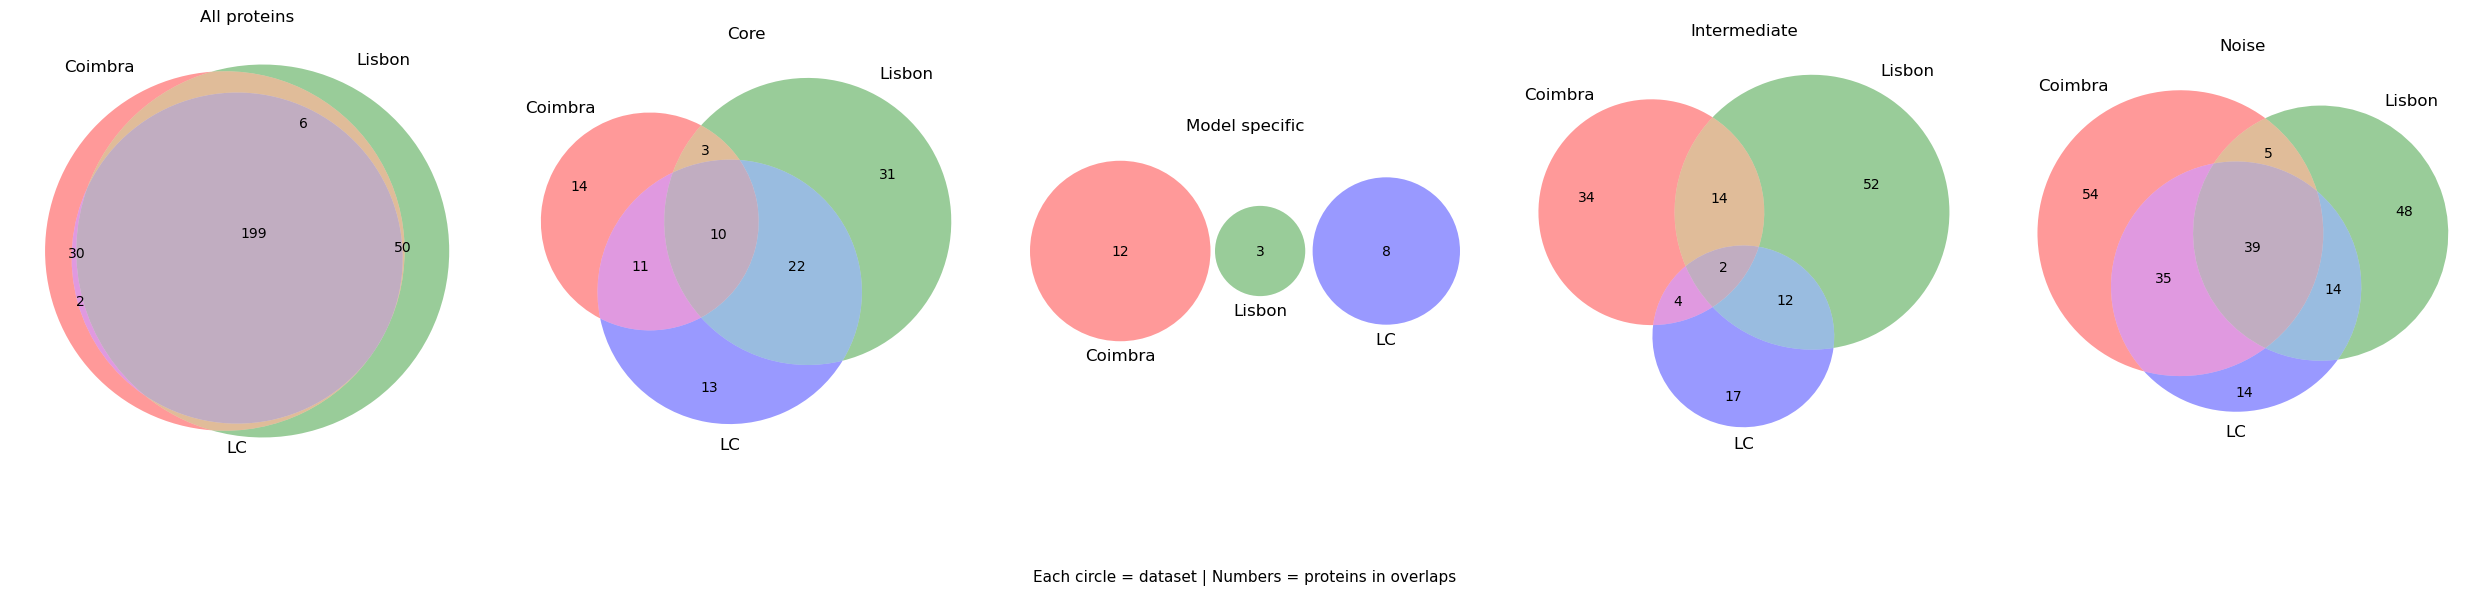

In [49]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

def get_sets(results, category=None):
    sets = {}
    for name, df in results.items():
        if category:
            sets[name] = set(df[df['category'] == category].index)
        else:
            sets[name] = set(df.index)
    return sets


def plot_multiple_venn(results):
    
    categories = [None, 'core', 'model_specific', 'intermediate', 'noise']
    titles = ['All proteins', 'Core', 'Model specific', 'Intermediate', 'Noise']
    
    # 🔧 FIX: 5 subplot + fig, axes
    fig, axes = plt.subplots(1, 5, figsize=(25,6))
    
    for i, (cat, title) in enumerate(zip(categories, titles)):
        
        sets = get_sets(results, category=cat)
        
        venn3(
            [sets["Coimbra"], sets["Lisbon"], sets["LC"]],
            set_labels=("Coimbra", "Lisbon", "LC"),
            ax=axes[i]
        )
        
        axes[i].set_title(title)
    
    # legenda
    fig.text(
        0.5, -0.05,
        "Each circle = dataset | Numbers = proteins in overlaps",
        ha='center', fontsize=11
    )
    
    plt.tight_layout()
    plt.savefig("venn_comparison_datasets.png", dpi=300, bbox_inches='tight')
    plt.show()


# ===== ESECUZIONE =====
plot_multiple_venn(results)